# Multi-model Bayesian model averaging on CANDELS galaxies

> ⚠️ **Experimental.** Uses experimental APIs that may change between releases.

SED fits are conditioned on modeling choices — SFH family, stellar library, dust law — that photometry alone cannot constrain. A single fit reports the posterior for one choice; BMA combines all four configurations by weighting each by its marginal likelihood (evidence). Evidence penalizes complexity (Occam factor) and requires nested sampling.

Four configurations varying SFH family, stellar isochrone, dust law, and ionization:

| Config | SFH | SSP | Dust law | Nebular |
|--------|-----|-----|----------|---------|
| A | Continuity (Leja+19) | MIST/C3K | Salim+2018 | $\log U=-3$ |
| B | Dirichlet (Leja+17) | PARSEC/MILES | Calzetti | $\log U=-3$ |
| C | Trunc. skew-normal | Padova/MILES | Kriek & Conroy | $\log U=-2$ |
| D | Double power-law | BaSTI/MILES | power-law | $\log U=-2$ |

All include nebular emission (wNE SSP grids). No dust IR emission — at $z\sim1$ the reddest band is below 5 µm rest-frame, and without far-IR photometry, dust emission does not constrain the fit.

$$w_k = \frac{Z_k}{\sum_j Z_j}, \qquad Z_k = \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta$$

In [1]:
from __future__ import annotations

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import gc
import hashlib
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

import tengri
from _setup import FIG_DIR, REPO_ROOT
from tengri import (
    FIXED,
    FREE,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
)
from tengri.units import ab_mag_to_fnu

## 0. Paths

In [2]:
DATA_DIR = REPO_ROOT / "data"
CANDELS_DIR = REPO_ROOT / "analysis" / "hst_proposal" / "data"
print(f"SSP grids : {DATA_DIR.exists()}")
print(f"CANDELS   : {CANDELS_DIR.exists()}")

SSP grids : True
CANDELS   : True


## 1. Catalog: CANDELS GOODS-South

AB magnitudes in 17 bands (HST/ACS, WFC3, NIR, IRAC); map to tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalog (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalog: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalog: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. Magnitude to flux, galaxy selection

Select star-forming galaxies at $z\sim1$ with $\ge10$ detected bands and clean flags.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalog


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# Seven z~1 star-forming galaxies that the models fit well. The first is the
# proposal target (CANDELS 4171); the rest were chosen from the high-S/N
# candidates by a quick MAP screen on their best-fit reduced chi^2 (so we show
# galaxies the four configurations actually reproduce, not pathological cases).
GAL_IDS = [4171, 17418, 16435, 16514, 18160, 15775, 13097]
SELECTED_IDX = [int(np.where(ids == g)[0][0]) for g in GAL_IDS]

print("Top candidates (z~1, ≥10 bands, clean flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if ids[idx] in GAL_IDS else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9
   18160  1.095    13    271.4  <--
   13097  1.097    13    271.4  <--
   16049  1.047    13    271.4
   16455  1.087    13    217.1
   15775  1.097    13    217.1  <--
   16435  1.094    13    217.1  <--


## 3. SSP libraries

Each config uses a different stellar library.

In [5]:
t0 = time.time()
# All four libraries are wNE (with-Nebular-Emission) DSPS grids: the nebular
# line + continuum emission is baked into the SSP at a fixed ionization
# parameter, so it is served from the precompute LUT at no extra cost. MIST and
# PARSEC are at logU = -3; Padova and BaSTI at logU = -2 (the FSPS default).
SSP = {
    "mist": tengri.load_ssp("ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0"),
    "padova": tengri.load_ssp("ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0"),
    "pdva": tengri.load_ssp("ssp_pdva_miles_chabrier_wNE_logGasU-2.0_logGasZ0.0"),
    "basti": tengri.load_ssp("ssp_bsti_miles_chabrier_wNE_logGasU-2.0_logGasZ0.0"),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

4 SSP libraries loaded in 0.4s


## 4. Model configurations

Each config: nested-dict grammar, `all_params=FIXED` except those with explicit `Uniform` priors; `approx=WavePrecomp()` for speed.

In [6]:
# Shared priors. Configs A and B use the two standard non-parametric SFHs —
# the continuity prior (Leja+2019) and the Dirichlet prior (Leja+2017). We keep
# their native priors on the bin variables (the continuity log-SFR ratios and the
# Dirichlet fractions), freeing them with the ``FREE`` sentinel; only total mass
# and metallicity get explicit uniform priors. (We previously used the Dense
# Basis prior here but dropped it: its quantile parameters are strongly
# degenerate, leaving the nested-sampling weights unstable from seed to seed.)
CONT_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    **{f"ratio_{i}": FREE for i in range(6)},  # Leja+2019 continuity log-SFR ratios
}
DIR_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    **{f"z_{i}": FREE for i in range(6)},  # Leja+2017 Dirichlet bin variables
}
# NO `law` here, deliberately: this fragment is splatted into each model's dict
# AFTER that dict names its own law, so a `law` in here would silently override
# all four and collapse the comparison to one curve (#1989 did exactly that).
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata (colors/labels match the published proposal figure)
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "pdva", "D": "basti"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Continuity / MIST / Salim / neb.",
    "B": "Dirichlet / PARSEC / Calzetti",
    "C": r"Trunc. Skew-Normal / Padova / K\&C",
    "D": "Double Power Law / BaSTI / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(
        observation=obs,
        redshift=Fixed(z),
        igm={"type": "inoue"},
        approx=WavePrecomp(),
    )

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={
            "type": "continuity",
            "all_params": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            **CONT_SFH,
        },
        dust_attenuation={"type": "two_component", "law": "salim_sbl18", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={
            "type": "dirichlet",
            "all_params": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            **DIR_SFH,
        },
        dust_attenuation={"type": "two_component", "law": "calzetti", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["pdva"],
        sfh={
            "type": "tsnorm",
            "all_params": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust_attenuation={"type": "two_component", "law": "kriek_conroy", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["basti"],
        sfh={
            "type": "dpl",
            "all_params": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust_attenuation={"type": "two_component", "law": "power_law", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit with three evidence routes

We compare three Bayesian evidence estimators:

- **NSS** (nested slice sampling): the calibrated reference; `preset="fast"` at n_live=100 (2-3× faster than n_live=250).
- **Laplace**: seconds-fast Gaussian approximation. On these 17-band fits its own validity
  diagnostics (Newton decrement, clipped eigenvalues) flag most configs as untrustworthy —
  the point of printing them is that the failure is *visible*, not silent.
- **HMC+IS**: HMC posterior + importance-sampled log Z. Tracks NSS closely on smooth parametric
  configs (D here); on the curved non-parametric SFH posteriors (A, B) a single Student-t
  proposal can miss mass and bias log Z low — the quoted error bar does not capture that, so
  watch `ess`/`max_weight_frac` and fall back to NSS where they warn.

The BMA *weights* are far more robust than the absolute log Z values: when one configuration
leads by tens-to-hundreds of nats (typical here), every route recovers the same weights even
where its absolute evidence is biased. NSS remains the reference whenever weights are close.

The notebook runs all three routes × 4 configurations per galaxy on a thread pool (XLA releases the GIL during compute). Seeds are deterministic for reproducibility.

In [7]:
N_POST = 1000  # posterior samples


def stable_seed(*parts):
    """Deterministic 31-bit seed from the given parts.

    Python's built-in ``hash`` is salted per process (``PYTHONHASHSEED``), so a
    key derived from ``hash((gal_id, cfg))`` changes every run and the nested
    sampling draws a different realization each time. Hashing the parts with
    ``hashlib`` instead makes every fit reproducible across sessions.
    """
    digest = hashlib.sha256("_".join(map(str, parts)).encode()).hexdigest()
    return int(digest, 16) % (2**31)


def fit_one(model, fnu, sigma, *, gal_id, cfg, method, **fit_kwargs):
    """Run one fit (any method); return ``(cfg, posterior, seconds)``."""
    key = jax.random.PRNGKey(stable_seed(gal_id, cfg, method))
    t = time.time()
    post = model.fit(
        fnu,
        sigma,
        method=method,
        key=key,
        **fit_kwargs,
        verbose=False,
    )
    return cfg, post, time.time() - t


HEADLINE_ROUTE = "hmc_is"  # which route to drive downstream figures/BMA (switch here)

ROUTES = {
    "nss": dict(method="nss", preset="fast", n_posterior_samples=N_POST),
    "laplace": dict(method="laplace"),
    "hmc_is": dict(method="hmc_is", n_samples=N_POST),
}

galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, fit_timings, ...)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma = extract_photometry(gal_idx)
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    # Run the routes SEQUENTIALLY, each with its own thread pool over the 4
    # configs. Mixing all 12 fits on one pool spikes peak memory (4 concurrent
    # HMC/Laplace fits at ~3-5 GB each on top of 4 SSP grids OOMs the kernel);
    # per-route pools keep the proven 4-way NSS pattern, with the HMC-based
    # route throttled to 2 workers. XLA releases the GIL during compute.
    posteriors, fit_timings = {}, {}
    for route in ROUTES:
        posteriors[route] = {}
        fit_timings[route] = {}

    # NSS at 2: its unrolled slice-sampling graphs are enormous during XLA
    # *compilation* (docs/dev/archive/2026-04-22-nss-memory-analysis.md), and on
    # a cold compile cache 4 concurrent NSS compiles OOM-kill the kernel.
    ROUTE_WORKERS = {"nss": 2, "laplace": 4, "hmc_is": 2}
    t_wall = time.time()
    for route, route_kwargs in ROUTES.items():
        with ThreadPoolExecutor(max_workers=ROUTE_WORKERS.get(route, 2)) as ex:
            futs = [
                (
                    cfg,
                    ex.submit(
                        fit_one, models[cfg], fnu, sigma, gal_id=gal_id, cfg=cfg, **route_kwargs
                    ),
                )
                for cfg in CONFIG_ORDER
            ]
            for cfg, fut in futs:
                _, post, dt = fut.result()
                posteriors[route][cfg] = post
                fit_timings[route][cfg] = dt

    for route in ROUTES:
        print(f"  {route}:")
        for cfg in CONFIG_ORDER:
            n_free = len(models[cfg].spec.free_params)
            logz = posteriors[route][cfg].log_evidence
            print(
                f"    [{cfg}] D={n_free:2d}  fit {fit_timings[route][cfg]:6.1f}s  logZ = {logz:8.1f}"
            )
    fit_wall_s = time.time() - t_wall
    print(f"  12 fits (threaded) wall-clock: {fit_wall_s:.1f}s")

    # Evict this galaxy's compiled backend state. Each galaxy builds fresh model
    # objects (per-z), so nothing is shared with the next galaxy — but the
    # resident XLA executables (3 backends x 4 configs) otherwise accumulate
    # across galaxies until the kernel OOMs. Later prediction cells re-JIT from
    # the persistent disk cache in seconds.
    from tengri.inference._model_cache import clear_model_cache

    for cfg in CONFIG_ORDER:
        clear_model_cache(models[cfg])
    gc.collect()

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
        fit_wall_s=fit_wall_s,
    )

print("\nAll fits complete.")


################################################################
# Galaxy CANDELS 4171  (z = 1.032, 11 bands)
################################################################


  built 4 models in 17.5s


  nss:
    [A] D=10  fit   42.7s  logZ =   -149.6
    [B] D=10  fit   33.8s  logZ =    -86.7
    [C] D= 8  fit   25.3s  logZ =   -519.4
    [D] D= 6  fit   21.8s  logZ =   -895.0
  laplace:
    [A] D=10  fit    3.3s  logZ =   -289.7
    [B] D=10  fit    3.2s  logZ =   -117.9
    [C] D= 8  fit    3.0s  logZ =   -579.0
    [D] D= 6  fit    3.0s  logZ =  -1098.7
  hmc_is:
    [A] D=10  fit   13.4s  logZ =   -223.4
    [B] D=10  fit   13.4s  logZ =   -100.0
    [C] D= 8  fit   14.6s  logZ =   -508.7
    [D] D= 6  fit   11.7s  logZ =  -1112.8
  12 fits (threaded) wall-clock: 95.8s



################################################################
# Galaxy CANDELS 17418  (z = 1.096, 12 bands)
################################################################


  built 4 models in 16.0s


...

  nss:
    [A] D=10  fit   29.8s  logZ =   -519.7
    [B] D=10  fit   21.0s  logZ =   -376.1
    [C] D= 8  fit   45.8s  logZ =   -849.3
    [D] D= 6  fit   20.4s  logZ =  -3136.4
  laplace:
    [A] D=10  fit    6.3s  logZ =   -669.9
    [B] D=10  fit    5.7s  logZ =  -3415.1
    [C] D= 8  fit    6.0s  logZ =  -1822.6
    [D] D= 6  fit    4.1s  logZ =  -3859.9
  hmc_is:
    [A] D=10  fit   13.4s  logZ =   -679.5
    [B] D=10  fit   10.8s  logZ =   -482.5
    [C] D= 8  fit   13.2s  logZ =  -1442.9
    [D] D= 6  fit   10.8s  logZ =  -3170.4
  12 fits (threaded) wall-clock: 97.2s



################################################################
# Galaxy CANDELS 13097  (z = 1.097, 13 bands)
################################################################


  built 4 models in 8.5s


  nss:
    [A] D=10  fit   47.7s  logZ =   -471.9
    [B] D=10  fit   23.5s  logZ =   -266.7
    [C] D= 8  fit   44.9s  logZ =  -2035.6
    [D] D= 6  fit   24.4s  logZ =  -4390.2
  laplace:
    [A] D=10  fit    3.5s  logZ =  -1082.6
    [B] D=10  fit    3.3s  logZ =   -420.7
    [C] D= 8  fit    3.3s  logZ =  -2765.2
    [D] D= 6  fit    3.4s  logZ =  -5121.5
  hmc_is:
    [A] D=10  fit   12.0s  logZ =   -866.6
    [B] D=10  fit    9.4s  logZ =   -380.1
    [C] D= 8  fit   12.8s  logZ =  -2237.9
    [D] D= 6  fit   10.5s  logZ =  -4391.3
  12 fits (threaded) wall-clock: 98.1s



All fits complete.


## 6. Three-route evidence comparison

For each galaxy and config, compare logZ and wall-time across the three routes.
Evidence precision and consistency validate the BMA setup.

In [8]:
from tengri import bma_weights


def route_weights(posts_by_cfg):
    """BMA weights over ``CONFIG_ORDER`` as an array.

    ``bma_weights`` is dict-in → dict-out; the notebook's plotting and pooling
    code wants a weight VECTOR in config order, so unpack it here once.
    """
    w = bma_weights({cfg: posts_by_cfg[cfg] for cfg in CONFIG_ORDER})
    return np.array([w[cfg] for cfg in CONFIG_ORDER])


def format_logz_with_err(posterior):
    """Return ``logZ`` string with error bar if available."""
    logz = posterior.log_evidence
    diag = posterior.diagnostics or {}
    # NSS: log_evidence_err; hmc_is: log_evidence_err; laplace: no err, show validity flags
    if "log_evidence_err" in diag:
        err = diag["log_evidence_err"]
        return f"{logz:8.1f}±{err:4.2f}"
    # Laplace: show validity flags instead
    nd = diag.get("newton_decrement", -1)
    clip = diag.get("n_clipped_eigenvalues", -1)
    if nd >= 0:
        return f"{logz:8.1f} (nd={nd:.2e}, clip={clip})"
    return f"{logz:8.1f}"


for gal_id, g in galaxies.items():
    print(f"\nCANDELS {gal_id}  (z = {g['z']:.3f}, {len(g['names'])} bands)")
    print(f"{'config':>8s}  {'NSS':>20s}  {'Laplace':>20s}  {'HMC+IS':>20s}")
    print(f"{'':>8s}  {'time [s]  logZ':>20s}  {'time [s]  logZ':>20s}  {'time [s]  logZ':>20s}")
    for cfg in CONFIG_ORDER:
        row_parts = [f"[{cfg}]"]
        for route in ["nss", "laplace", "hmc_is"]:
            dt = g["fit_timings"][route][cfg]
            post = g["posteriors"][route][cfg]
            logz_str = format_logz_with_err(post)
            row_parts.append(f"{dt:6.1f}   {logz_str}")
        print("  ".join([f"{row_parts[0]:>8s}", *row_parts[1:]]))

    # BMA weights per route
    print("  BMA weights (softmax of logZ):")
    try:
        w_nss = route_weights(g["posteriors"]["nss"])
        w_lap = route_weights(g["posteriors"]["laplace"])
        w_hmc = route_weights(g["posteriors"]["hmc_is"])
        print(f"    NSS:     {' '.join(f'{c}={w:.2f}' for c, w in zip(CONFIG_ORDER, w_nss))}")
        print(f"    Laplace: {' '.join(f'{c}={w:.2f}' for c, w in zip(CONFIG_ORDER, w_lap))}")
        print(f"    HMC+IS:  {' '.join(f'{c}={w:.2f}' for c, w in zip(CONFIG_ORDER, w_hmc))}")

        # Consistency check: max |Δw| and ranking agreement
        delta_nss_lap = np.abs(w_nss - w_lap).max()
        delta_nss_hmc = np.abs(w_nss - w_hmc).max()
        delta_lap_hmc = np.abs(w_lap - w_hmc).max()
        max_delta = max(delta_nss_lap, delta_nss_hmc, delta_lap_hmc)

        rank_nss = np.argsort(-w_nss)
        rank_lap = np.argsort(-w_lap)
        rank_hmc = np.argsort(-w_hmc)
        rank_agree = np.array_equal(rank_nss, rank_lap) and np.array_equal(rank_lap, rank_hmc)

        print(f"  Consistency: max |Δw| = {max_delta:.3f}, ranking agree = {rank_agree}")
        if max_delta > 0.1:
            print(
                "    ⚠ weight disagreement > 0.1 (Laplace may flag non-Gaussian posterior or HMC+IS error < 500)"
            )
    except ValueError as e:
        print(f"  ⚠ BMA weight error: {e}")


CANDELS 4171  (z = 1.032, 11 bands)
  config                   NSS               Laplace                HMC+IS
                time [s]  logZ        time [s]  logZ        time [s]  logZ
     [A]    42.7     -149.6±0.29     3.3     -289.7 (nd=1.32e+09, clip=3)    13.4     -223.4±1.00
     [B]    33.8      -86.7±0.24     3.2     -117.9 (nd=1.97e+01, clip=0)    13.4     -100.0±0.57
     [C]    25.3     -519.4±0.28     3.0     -579.0 (nd=1.19e+08, clip=1)    14.6     -508.7±0.43
     [D]    21.8     -895.0±0.26     3.0    -1098.7 (nd=1.80e+02, clip=0)    11.7    -1112.8±0.90
  BMA weights (softmax of logZ):
    NSS:     A=0.00 B=1.00 C=0.00 D=0.00
    Laplace: A=0.00 B=1.00 C=0.00 D=0.00
    HMC+IS:  A=0.00 B=1.00 C=0.00 D=0.00
  Consistency: max |Δw| = 0.000, ranking agree = True

CANDELS 17418  (z = 1.096, 12 bands)
  config                   NSS               Laplace                HMC+IS
                time [s]  logZ        time [s]  logZ        time [s]  logZ
     [A]    50.9    -17

Evidence comparison figure: relative logZ per config per route, across all galaxies.
Routes agreeing within error bars ⇒ consistent BMA weights; fast routes reproduce NSS ranking at a fraction of the cost.

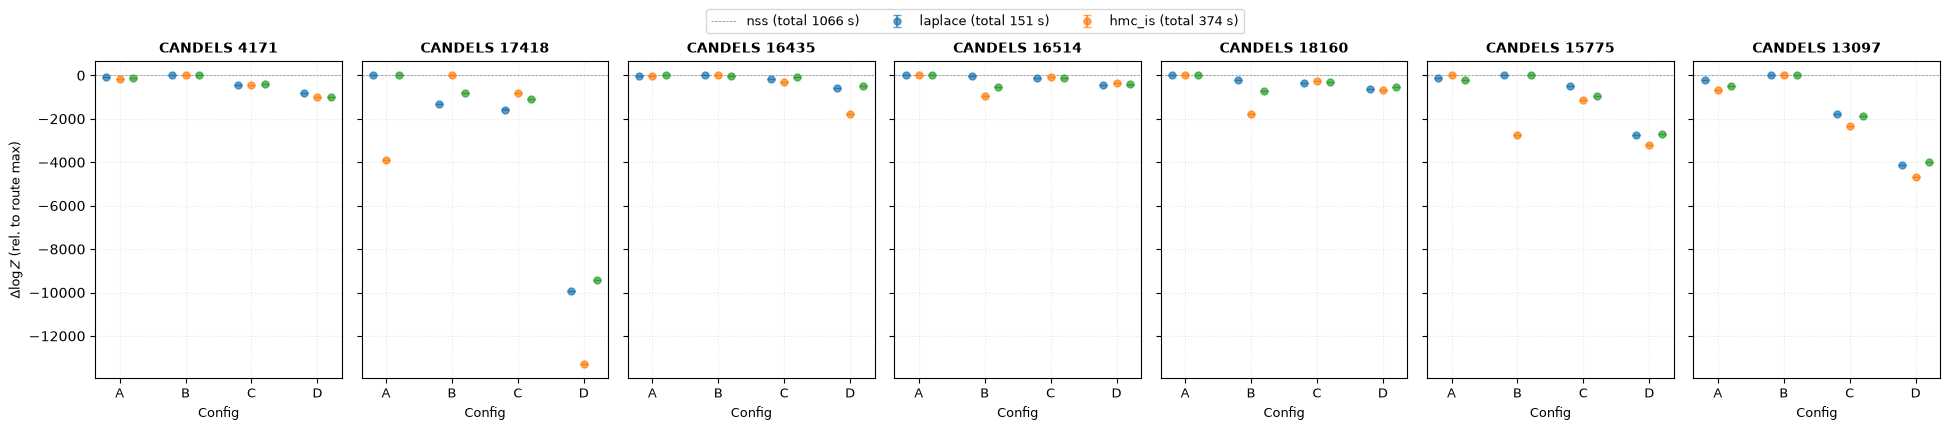

Figure saved: multimodel_bma_candels_evidence_routes.png


In [9]:
# Compute per-route wall-times (summed over all galaxies).
wall_times_per_route = {route: 0.0 for route in ROUTES}
for _gal_id, g in galaxies.items():
    for route in ROUTES:
        wall_times_per_route[route] += sum(g["fit_timings"][route].values())

# Collect Δ logZ: logZ - max(logZ) per galaxy per route.
# This is the actual quantity used in BMA weights (softmax of logZ differences).
delta_logz_data = {}  # {gal_id: {route: {cfg: (logz_diff, err)}}}
for gal_id, g in galaxies.items():
    delta_logz_data[gal_id] = {}
    for route in ROUTES:
        logz_vals = np.array([g["posteriors"][route][cfg].log_evidence for cfg in CONFIG_ORDER])
        max_logz = logz_vals.max()
        deltas = logz_vals - max_logz
        errs = np.zeros(len(CONFIG_ORDER))
        for i, cfg in enumerate(CONFIG_ORDER):
            post = g["posteriors"][route][cfg]
            diag = post.diagnostics or {}
            if "log_evidence_err" in diag:
                errs[i] = diag["log_evidence_err"]
        delta_logz_data[gal_id][route] = {
            cfg: (deltas[i], errs[i]) for i, cfg in enumerate(CONFIG_ORDER)
        }

# Figure: one panel per galaxy, x = configs, y = Δ logZ per route.
n_gal = len(galaxies)
figsize_w = max(12, 2.8 * n_gal)
fig, axes = plt.subplots(1, n_gal, figsize=(figsize_w, 4.0), sharey=True)
if n_gal == 1:
    axes = [axes]

for ax_idx, (gal_id, _g) in enumerate(galaxies.items()):
    ax = axes[ax_idx]
    x_cfg = np.arange(len(CONFIG_ORDER))
    route_offsets = {"nss": -0.2, "laplace": 0.0, "hmc_is": 0.2}
    route_colors = {"nss": "C0", "laplace": "C1", "hmc_is": "C2"}

    for route in ROUTES:
        x_pos = x_cfg + route_offsets[route]
        deltas = np.array([delta_logz_data[gal_id][route][cfg][0] for cfg in CONFIG_ORDER])
        errs = np.array([delta_logz_data[gal_id][route][cfg][1] for cfg in CONFIG_ORDER])
        ax.errorbar(
            x_pos,
            deltas,
            yerr=errs,
            fmt="o",
            ms=5,
            capsize=3,
            capthick=1,
            color=route_colors[route],
            alpha=0.7,
            label=route,
            zorder=3,
        )

    ax.set_xticks(x_cfg)
    ax.set_xticklabels(CONFIG_ORDER, fontsize=9)
    ax.set_xlabel("Config", fontsize=9)
    if ax_idx == 0:
        ax.set_ylabel(r"$\Delta \log Z$ (rel. to route max)", fontsize=9)
    ax.set_title(f"CANDELS {gal_id}", fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle=":")
    ax.axhline(0, color="k", linestyle="--", linewidth=0.5, alpha=0.5, zorder=1)

# Shared legend at the top with wall-times.
fig.legend(
    [f"{route} (total {wall_times_per_route[route]:.0f} s)" for route in ROUTES],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    fontsize=9,
    frameon=True,
)

fig.tight_layout(rect=[0, 0, 1, 1.02])
fig.savefig(FIG_DIR / "multimodel_bma_candels_evidence_routes.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved: multimodel_bma_candels_evidence_routes.png")

## 8. Timing summary

In [10]:
print("\nWall-clock per route (12 fits per galaxy, 4 configs × 3 routes):")
print(f"{'Galaxy':>14s} {'build':>7s} {'NSS':>8s} {'Laplace':>8s} {'HMC+IS':>8s} {'total':>8s}")
for gal_id, g in galaxies.items():
    wall_nss = sum(g["fit_timings"]["nss"].values())
    wall_lap = sum(g["fit_timings"]["laplace"].values())
    wall_hmc = sum(g["fit_timings"]["hmc_is"].values())
    total = g["build_s"] + g["fit_wall_s"]
    print(
        f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {wall_nss:8.1f} {wall_lap:8.1f} "
        f"{wall_hmc:8.1f} {total:8.1f}"
    )
print("(seconds; wall-clock = sum of individual fit times per route, not concurrent total.)")
print(
    "(True wall-clock = build + fit_wall_s = build + max(NSS, Laplace, HMC+IS) due to threading.)"
)


Wall-clock per route (12 fits per galaxy, 4 configs × 3 routes):
        Galaxy   build      NSS  Laplace   HMC+IS    total
CANDELS   4171    17.5    123.7     12.5     53.1    113.3
CANDELS  17418    16.0    194.9     23.0     75.1    160.1
CANDELS  16435    24.6    282.4     25.7     52.3    202.8
CANDELS  16514     9.2    106.4     26.4     50.4     99.3
CANDELS  18160     8.6    100.7     27.7     49.7     98.6
CANDELS  15775     7.9    116.9     22.1     48.2    105.1
CANDELS  13097     8.5    140.6     13.5     44.7    106.6
(seconds; wall-clock = sum of individual fit times per route, not concurrent total.)
(True wall-clock = build + fit_wall_s = build + max(NSS, Laplace, HMC+IS) due to threading.)


## 9. Posterior predictions and BMA

Draw posterior SEDs, SFHs, and $(M_\star, \mathrm{SFR})$ from the headline route (HMC+IS).
BMA weights pool configurations by evidence from the headline route.

In [11]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)


# Effective wavelengths + half-widths [Å] of the catalog bands, computed from
# the *actual* filter transmission curves (single source of truth — not
# hardcoded): mean effective wavelength and rectangular-equivalent half-width
# W/2 = (1/2) ∫T dλ / max(T), used for the photometry x error bars.
def _filter_eff_and_halfwidth(names):
    phot = Photometry.from_names(names)
    eff, half = {}, {}
    for i, nm in enumerate(phot.names):
        w = np.asarray(phot.filter_waves[i], dtype=float)
        t = np.asarray(phot.filter_trans[i], dtype=float)
        good = t > 0
        w, t = w[good], t[good]
        eff[nm] = float(np.trapezoid(w * t, w) / np.trapezoid(t, w))
        half[nm] = float(0.5 * np.trapezoid(t, w) / t.max())
    return eff, half


WAVE_EFF, FILTER_HALFWIDTH = _filter_eff_and_halfwidth(filter_names)


def bin_to_grid(wave, y, grid):
    """Downsample ``y(wave)`` onto ``grid`` by mean within log-spaced bins.

    A binned mean (rather than point interpolation) keeps narrow nebular
    emission lines at the *resolution of the plot grid* — so they appear as
    modest bumps rather than aliased full-height spikes, matching a coarsely
    sampled spectrum.
    """
    edges = np.empty(len(grid) + 1)
    edges[1:-1] = np.sqrt(grid[1:] * grid[:-1])
    edges[0], edges[-1] = grid[0], grid[-1]
    tot, _ = np.histogram(wave, bins=edges, weights=y)
    cnt, _ = np.histogram(wave, bins=edges)
    out = np.divide(tot, cnt, out=np.full_like(tot, np.nan), where=cnt > 0)
    empty = ~np.isfinite(out)
    if empty.any():  # fill any empty bins by interpolation from filled ones
        out[empty] = np.interp(grid[empty], grid[~empty], out[~empty])
    return out


def vmap_chunked(fn, batch, n, chunk=16):
    """``jax.jit(jax.vmap(fn))`` over an ``n``-draw batch in memory-bounded chunks.

    A bare ``vmap`` only batches eager ops (slower than the loop); ``jax.jit``
    compiles the batched forward into one kernel (~7x). vmapping all draws at
    once OOMs, so we chunk (peak memory ~ ``chunk``; the final partial chunk
    triggers one extra cheap compile). Results concatenate along the draw axis.
    """
    vfn = jax.jit(jax.vmap(fn))
    parts = [vfn({k: v[s : s + chunk] for k, v in batch.items()}) for s in range(0, n, chunk)]
    return jax.tree_util.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *parts)


def collect_predictions(g, route):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR) from a given route.

    The continuous SED is the observed-frame model spectrum: ``predict_spectrum``
    evaluated on each SSP's native (line-resolved) grid, which returns observed
    :math:`f_\\nu = L_\\nu (1+z) / (4\\pi d_L^2)` directly (suchethac/tengri#707),
    then binned onto the common ``WAVE_SPEC`` grid so the four configs can be
    pooled for the BMA predictive. Binning the native grid (rather than
    point-sampling on the coarse plot grid) keeps narrow nebular lines as modest,
    area-correct bumps instead of aliased spikes.

    SED and derived (M*, SFR) draws use chunked ``jax.jit(jax.vmap)`` (~7x vs a
    Python loop) over ``predict_spectrum`` / ``predict_properties`` — the
    JIT/vmap-safe surfaces (NAMING_CONTRACT §4b). The rich ``predict`` object and
    its ``properties`` are deliberately *not* pytrees, so they cannot cross a
    ``vmap``; only the single eager call for the wavelength grid may use them.
    ``predict_sfh`` is not jittable (``ConcretizationTypeError``), so the SFH
    curve stays an eager loop.
    """
    spec, sfh, props = {}, {}, {}
    posteriors = g["posteriors"][route]
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = posteriors[cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)
        batch = {k: v[:n_use] for k, v in samples.items()}

        # Observed-frame wavelength grid (config-fixed, so a single eager call).
        s0 = {k: v[0] for k, v in samples.items()}
        wave_nat = np.asarray(model.predict(s0).wave_obs)

        # SED: chunked jit(vmap) over predict_spectrum on that native grid, which
        # already returns observed f_nu -- no manual L_nu -> f_nu conversion.
        # Default args bind the loop variables into the lambdas (ruff B023).
        fnu_b = np.asarray(
            vmap_chunked(
                lambda p, m=model, w=wave_nat: m.predict_spectrum(p, wave_obs=w), batch, n_use
            )
        )
        spec[cfg] = np.array([bin_to_grid(wave_nat, fnu_b[i], WAVE_SPEC) for i in range(n_use)])

        # Derived quantities: predict_properties is the single JIT/vmap surface.
        q = vmap_chunked(
            lambda p, m=model: m.predict_properties(p, names=("stellar_mass", "sfr_100myr")),
            batch,
            n_use,
        )
        props[cfg] = {
            "log_mass": np.log10(np.maximum(np.asarray(q["stellar_mass"]) * RETURN_FRAC, 1e-30)),
            "log_sfr": np.log10(np.maximum(np.asarray(q["sfr_100myr"]), 1e-30)),
        }

        # SFH curve: eager loop (predict_sfh is not jittable).
        sfr_arr, t_gyr = [], None
        for i in range(min(n_use, N_SFH)):
            out = model.predict_sfh({k: v[i] for k, v in samples.items()})
            t_gyr = np.asarray(out["t_gyr"]) if t_gyr is None else t_gyr
            sfr_arr.append(np.asarray(out["sfr_full"]))
        sfh[cfg] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = route_weights(g["posteriors"][HEADLINE_ROUTE])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g, HEADLINE_ROUTE)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights ({HEADLINE_ROUTE}):  {wstr}")

CANDELS 4171  BMA weights (hmc_is):  A=0.00  B=1.00  C=0.00  D=0.00


CANDELS 17418  BMA weights (hmc_is):  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 16435  BMA weights (hmc_is):  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 16514  BMA weights (hmc_is):  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 18160  BMA weights (hmc_is):  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 15775  BMA weights (hmc_is):  A=0.00  B=1.00  C=0.00  D=0.00


CANDELS 13097  BMA weights (hmc_is):  A=0.00  B=1.00  C=0.00  D=0.00


## 10. Figures

Three panels per galaxy: (a) photometry over posterior predictive spectra (color per config, black for BMA); (b) inferred SFHs; (c) $M_\star$-SFR posteriors (68/95% contours per config, BMA outline). The BMA contour is broader because it includes between-model uncertainty.

In [12]:
import scienceplots

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 220,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

POINT_COLOR = "#e8000b"  # red photometry markers (matches proposal figure)
# FILTER_HALFWIDTH is computed from the real transmission curves above (the x
# error bars on the photometry are the filters' rectangular-equivalent widths).


def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def pool_pairs(per_cfg_x, per_cfg_y, weights, total):
    """Evidence-weighted pool of *paired* (x, y) draws — one index set per config.

    Keeps the (M*, SFR) correlation intact; pooling x and y with independent
    ``rng.choice`` calls would decorrelate them and misplace the BMA contour.
    """
    xs, ys = [], []
    for cfg, w in zip(CONFIG_ORDER, weights):
        x, y = per_cfg_x[cfg], per_cfg_y[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(x), size=min(n, len(x)), replace=True)
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)


def filled_kde(ax, x, y, color, *, zorder=2, fill=True, lw=2.0):
    """68/95% credible contours of a 2-D KDE.

    ``fill=True`` shades the contours (used for the individual models);
    ``fill=False`` draws outline-only 68/95 lines (used for the BMA, so the
    averaged result is never shaded over the models). Falls back to a point
    marker for a degenerate (near-zero-variance) posterior.
    """
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 4 * x.std(), x.mean() + 4 * x.std(), 120)
    yg = np.linspace(y.mean() - 4 * y.std(), y.mean() + 4 * y.std(), 120)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    zmax = ZG.max()
    if not (l95 < l68 < zmax):
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    if fill:
        ax.contourf(XG, YG, ZG, levels=[l95, l68, zmax], colors=[color, color],
                    alpha=0.30, zorder=zorder)  # fmt: skip
        ax.contourf(XG, YG, ZG, levels=[l68, zmax], colors=[color], alpha=0.35, zorder=zorder)
        ax.contour(XG, YG, ZG, levels=[l95], colors=[color], linewidths=0.4,
                   alpha=0.9, zorder=zorder + 0.1)  # fmt: skip
    else:  # outline only (BMA): two lines, no shading
        ax.contour(XG, YG, ZG, levels=[l95, l68], colors=[color], linewidths=[lw * 0.6, lw],
                   alpha=0.95, zorder=zorder)  # fmt: skip


def _span(arrays, k=4.0):
    """Union of ``mean +/- k*std`` across several 1-D samples (for axis limits)."""
    los, his = [], []
    for a in arrays:
        a = a[np.isfinite(a)]
        if a.size:
            los.append(a.mean() - k * a.std())
            his.append(a.mean() + k * a.std())
    return min(los), max(his)


def plot_galaxy(gal_id, *, source=None, tag=""):
    """Render the three-panel multi-model + BMA figure for one galaxy.

    ``source`` selects the results dict (defaults to ``galaxies``); ``tag`` is
    appended to the saved filename for the error-floor variants
    (``source=galaxies_floor``, ``tag="_floor"``).
    """
    g = (source if source is not None else galaxies)[gal_id]
    w = g["weights"]
    fs_pan, fs_lab, fs_tick, fs_box = 16, 15, 12, 13
    lw_cfg, lw_bma, ms, ew = 1.8, 3.2, 7.5, 1.4

    fig = plt.figure(figsize=(13.0, 3.7))
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.0],
                  wspace=0.42, left=0.07, right=0.985, bottom=0.17, top=0.84)  # fmt: skip

    def panel_label(ax, s):
        ax.text(0.04, 0.93, s, transform=ax.transAxes, fontsize=fs_pan, va="top")

    # ---- (a) posterior predictive spectrum ----
    ax = fig.add_subplot(gs[0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(WAVE_SPEC, np.percentile(d, 16, 0), np.percentile(d, 84, 0),
                        color=COLORS[cfg], alpha=0.16, lw=0)  # fmt: skip
        ax.plot(WAVE_SPEC, np.median(d, 0), "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    # BMA shown as a line only (not shaded) so it never hides the model bands.
    ax.plot(WAVE_SPEC, np.median(bma, 0), "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    xerr = np.array([FILTER_HALFWIDTH[n] for n in g["names"]])  # real filter half-widths
    ax.errorbar(wobs, g["fnu"], yerr=g["sigma"], xerr=xerr, fmt="o", ms=ms,
                color=POINT_COLOR, ecolor="0.3", elinewidth=ew, capsize=0,
                markeredgewidth=0, zorder=10)  # fmt: skip
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3200, 1e5)
    fnu_pos = g["fnu"][g["fnu"] > 0]
    ax.set_ylim(0.3 * fnu_pos.min(), 4 * fnu_pos.max())  # frame on the data
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]", fontsize=fs_lab)
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(a)}$")
    ax.text(
        0.96, 0.08, f"CANDELS {gal_id}\n$z = {g['z']:.3f}$", transform=ax.transAxes,
        fontsize=fs_box, ha="right", va="bottom",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "0.7", "lw": 0.5, "alpha": 0.9},
    )  # fmt: skip

    # ---- (b) star-formation history ----
    ax = fig.add_subplot(gs[1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(t, np.percentile(sfr, 16, 0), np.percentile(sfr, 84, 0),
                        color=COLORS[cfg], alpha=0.15, lw=0)  # fmt: skip
        ax.plot(t, med, "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.9)
        maxes.append(np.max(med[(t >= 0.15) & (t < 5)]))  # ignore the t->0 instantaneous spike
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    bma_med = np.median(bma_sfr, 0)
    # BMA as a line only (not shaded).
    ax.plot(t_common, bma_med, "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95)
    maxes.append(np.max(bma_med[(t_common >= 0.15) & (t_common < 5)]))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1.25 * max(maxes))  # robust: fills the panel, ignores t->0 spike
    ax.set_xlabel("Lookback time [Gyr]", fontsize=fs_lab)
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(b)}$")

    # ---- (c) M*-SFR posterior ----
    ax = fig.add_subplot(gs[2])
    for cfg in CONFIG_ORDER:
        filled_kde(ax, g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"],
                   COLORS[cfg], zorder=3)  # fmt: skip
    bm, bs = pool_pairs(
        {c: g["props"][c]["log_mass"] for c in CONFIG_ORDER},
        {c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER},
        w, 2000,
    )  # fmt: skip
    filled_kde(ax, bm, bs, BMA_COLOR, zorder=6, fill=False, lw=lw_bma)  # outline, not shaded
    # Zoom out to enclose every configuration AND the broader BMA contour (which
    # the 95% lines of the per-model fits alone would clip), with generous padding.
    m_arrs = [g["props"][c]["log_mass"] for c in CONFIG_ORDER] + [bm]
    s_arrs = [g["props"][c]["log_sfr"] for c in CONFIG_ORDER] + [bs]
    lo_m, hi_m = _span(m_arrs)
    lo_s, hi_s = _span(s_arrs)
    px = 0.15 * (hi_m - lo_m + 1e-3)
    py = 0.15 * (hi_s - lo_s + 1e-3)
    ax.set_xlim(lo_m - px, hi_m + px)
    ax.set_ylim(lo_s - py, hi_s + py)
    ax.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$", fontsize=fs_lab)
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(c)}$")

    # Shared legend across the top, two rows (3 + 2 entries).
    handles = [Line2D([0], [0], color=COLORS[c], lw=2.2, label=LABELS[c]) for c in CONFIG_ORDER]
    handles.append(Line2D([0], [0], color=BMA_COLOR, lw=3.0, label="Bayesian Model Avg."))
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=3,
               fontsize=12, frameon=True, edgecolor="0.7", framealpha=0.95,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.4, labelspacing=0.3)  # fmt: skip

    fig.savefig(
        FIG_DIR / f"multimodel_bma_candels_{gal_id}{tag}.png", dpi=200, bbox_inches="tight"
    )
    plt.show()
    wstr_print = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    print(f"CANDELS {gal_id}: BMA weights  {wstr_print}")


def show_timings(gal_id):
    """Per-galaxy timing + evidence breakdown (headline route: HMC+IS)."""
    g = galaxies[gal_id]
    print(f"CANDELS {gal_id}  (z = {g['z']:.3f}, {len(g['names'])} bands) — {HEADLINE_ROUTE}")
    print(f"  build (4 models, incl. precompute publish + first compile): {g['build_s']:5.1f} s")
    print(f"  {'configuration':<34s} {'D':>2s} {'fit [s]':>8s} {'log Z':>9s}")
    for cfg in CONFIG_ORDER:
        n_free = len(g["models"][cfg].spec.free_params)
        print(
            f"  {LABELS[cfg]:<34s} {n_free:>2d} "
            f"{g['fit_timings'][HEADLINE_ROUTE][cfg]:>8.1f} "
            f"{g['posteriors'][HEADLINE_ROUTE][cfg].log_evidence:>9.1f}"
        )
    print(
        f"  {'4-config threaded wall-clock':<34s} {'':>2s} {g.get('fit_wall_s', 0.0):>8.1f}"
        f"   (vs {sum(g['fit_timings'][HEADLINE_ROUTE].values()):.1f}s summed)"
    )

### CANDELS 4171

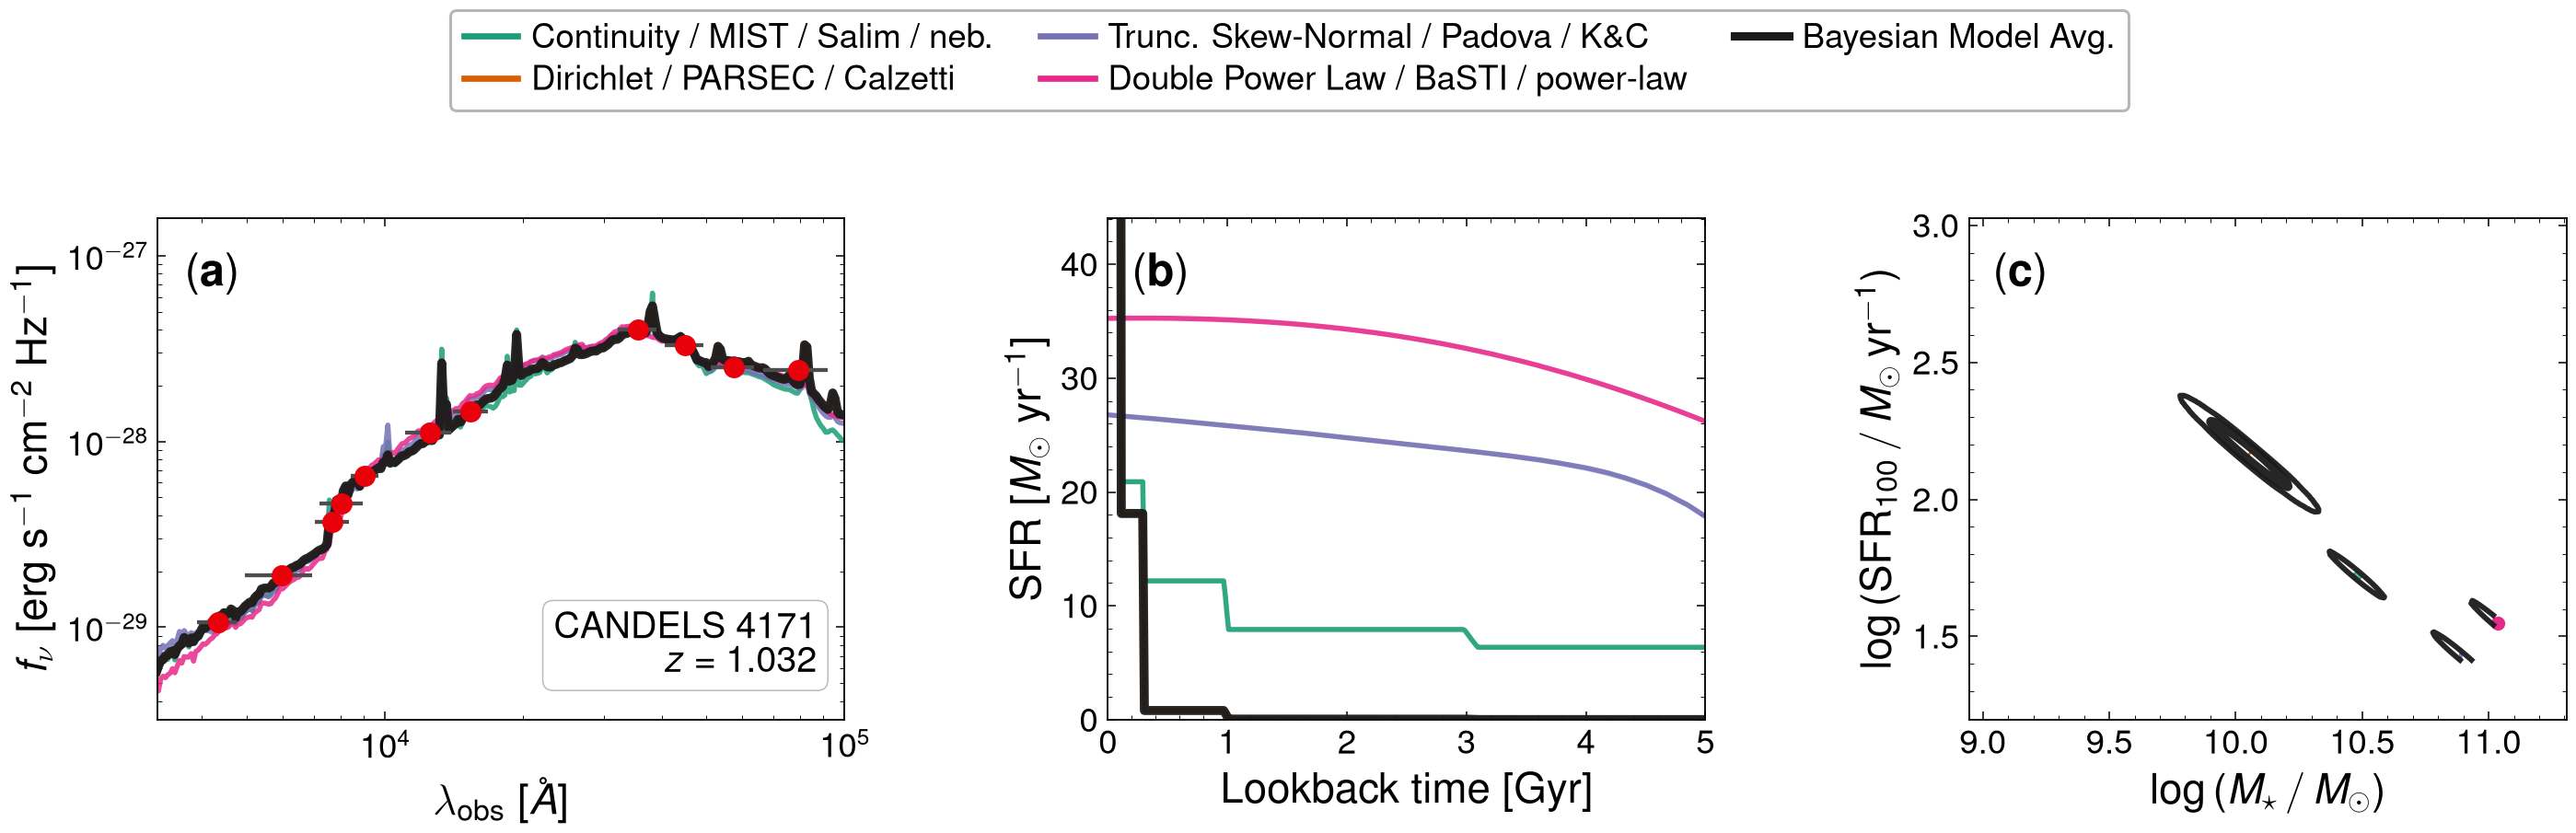

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [13]:
plot_galaxy(4171)

In [14]:
show_timings(4171)

CANDELS 4171  (z = 1.032, 11 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):  17.5 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     13.4    -223.4
  Dirichlet / PARSEC / Calzetti      10     13.4    -100.0
  Trunc. Skew-Normal / Padova / K\&C  8     14.6    -508.7
  Double Power Law / BaSTI / power-law  6     11.7   -1112.8
  4-config threaded wall-clock              95.8   (vs 53.1s summed)


### CANDELS 17418

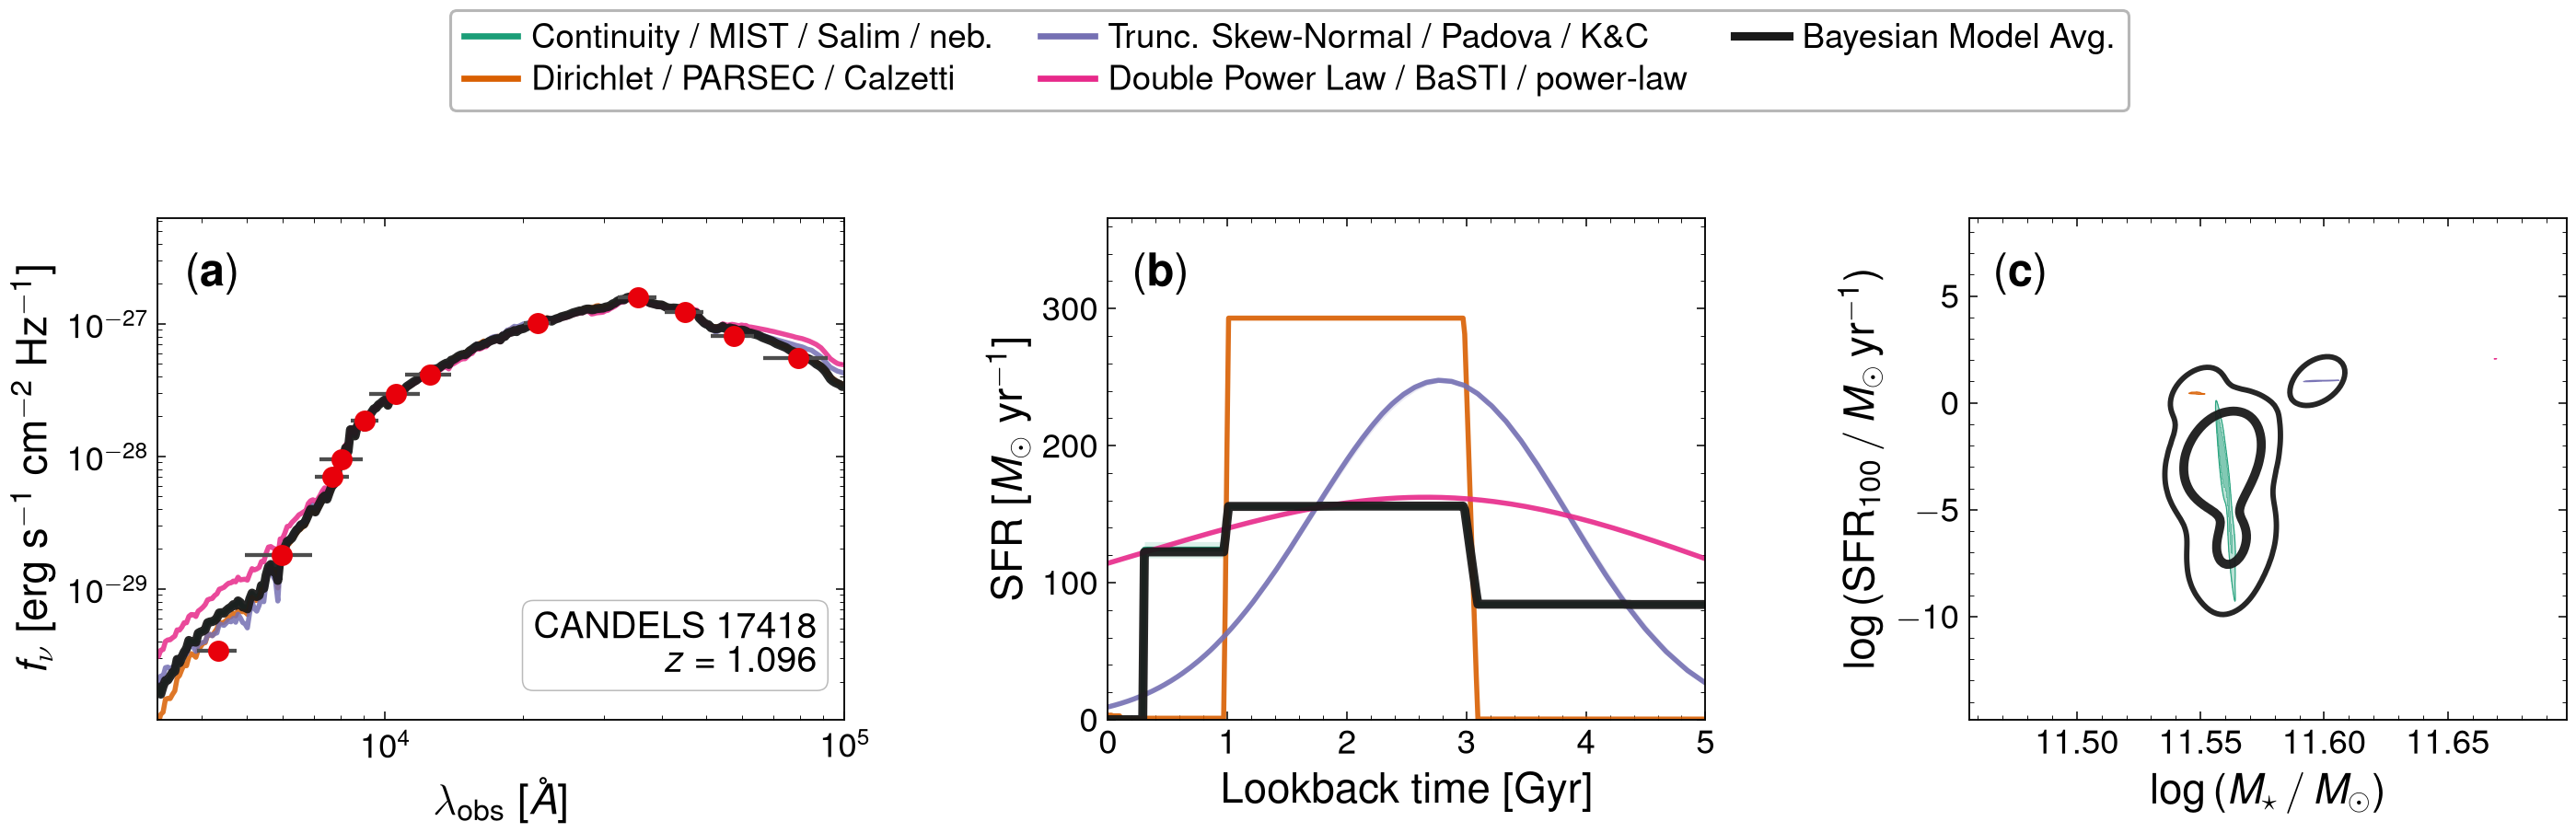

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [15]:
plot_galaxy(17418)

In [16]:
show_timings(17418)

CANDELS 17418  (z = 1.096, 12 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):  16.0 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     18.1   -2300.2
  Dirichlet / PARSEC / Calzetti      10     13.4   -3118.3
  Trunc. Skew-Normal / Padova / K\&C  8     25.5   -3396.1
  Double Power Law / BaSTI / power-law  6     18.2  -11736.8
  4-config threaded wall-clock             144.1   (vs 75.1s summed)


### CANDELS 16435

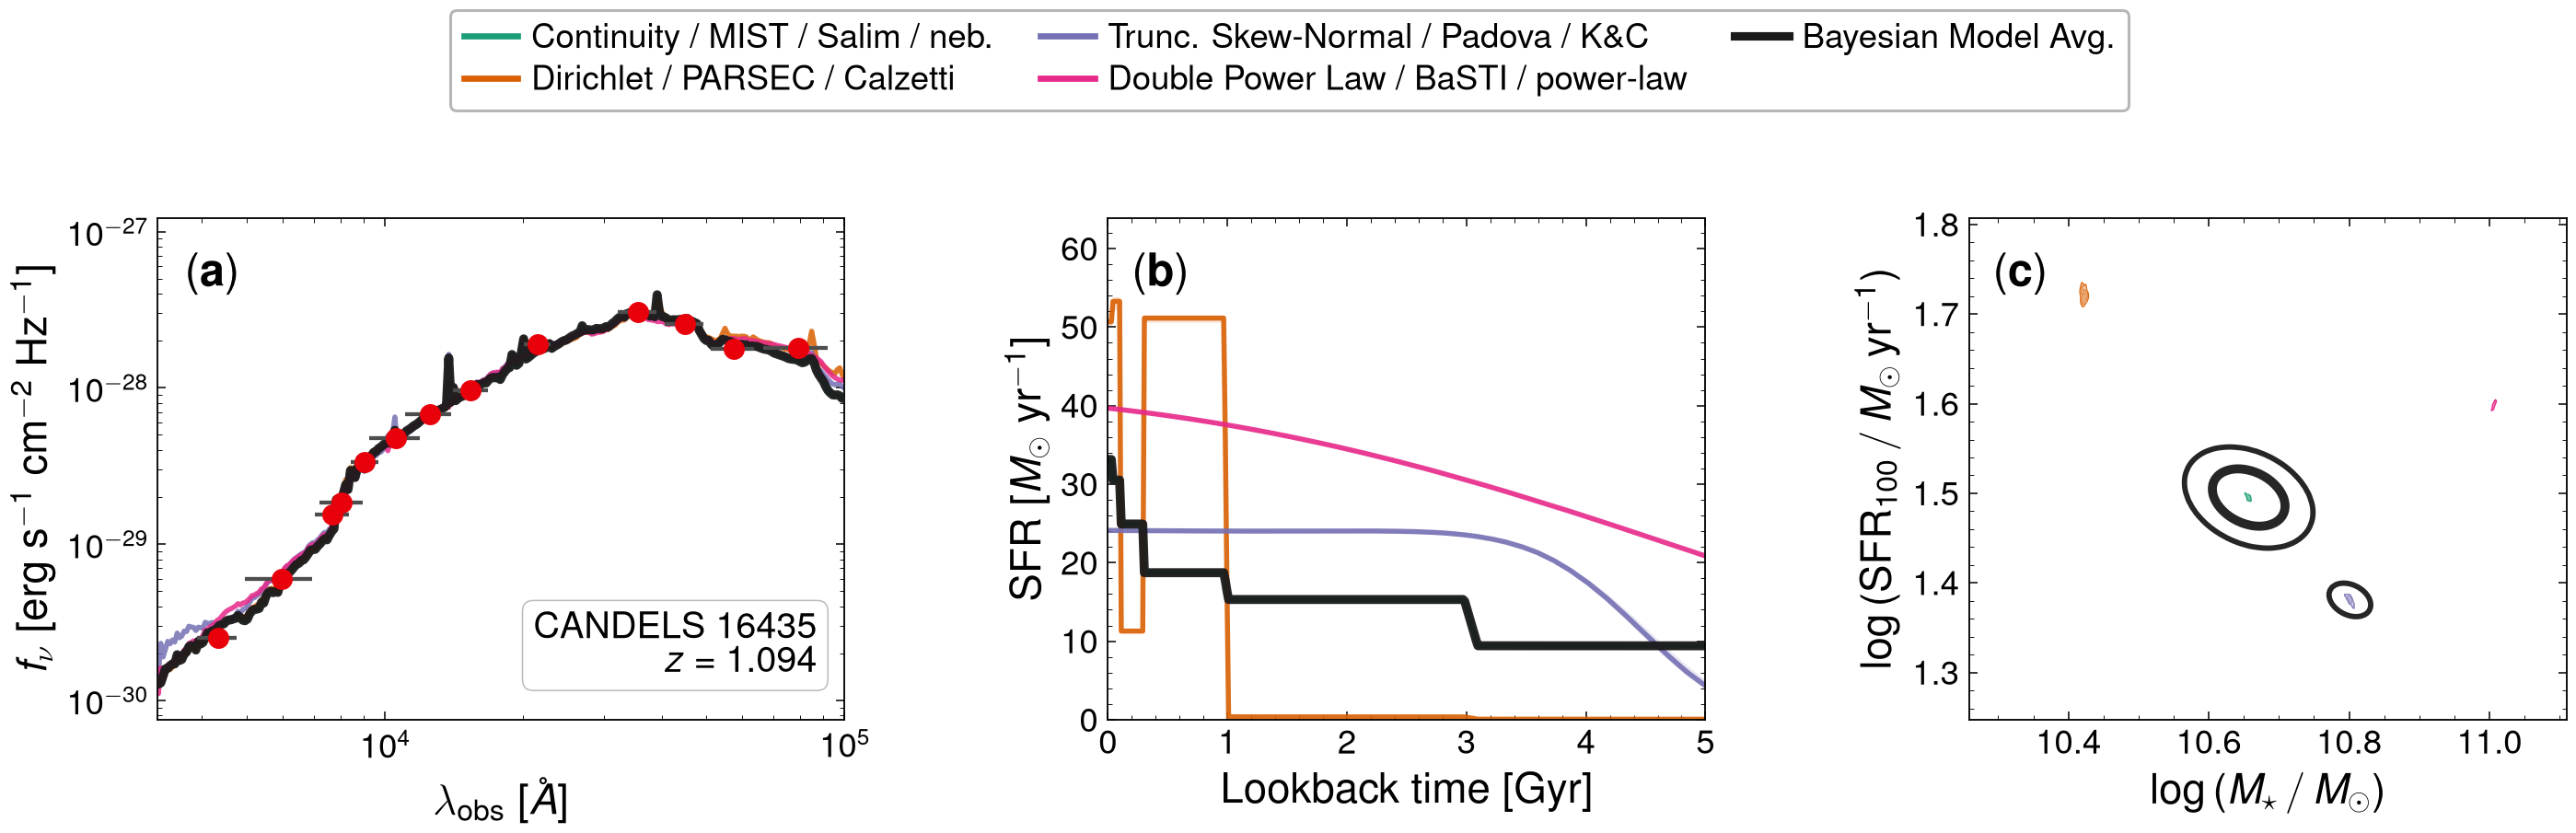

CANDELS 16435: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [17]:
plot_galaxy(16435)

In [18]:
show_timings(16435)

CANDELS 16435  (z = 1.094, 13 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):  24.6 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     13.7    -315.1
  Dirichlet / PARSEC / Calzetti      10     11.5    -325.6
  Trunc. Skew-Normal / Padova / K\&C  8     15.3    -409.7
  Double Power Law / BaSTI / power-law  6     11.9    -819.0
  4-config threaded wall-clock             178.2   (vs 52.3s summed)


### CANDELS 16514

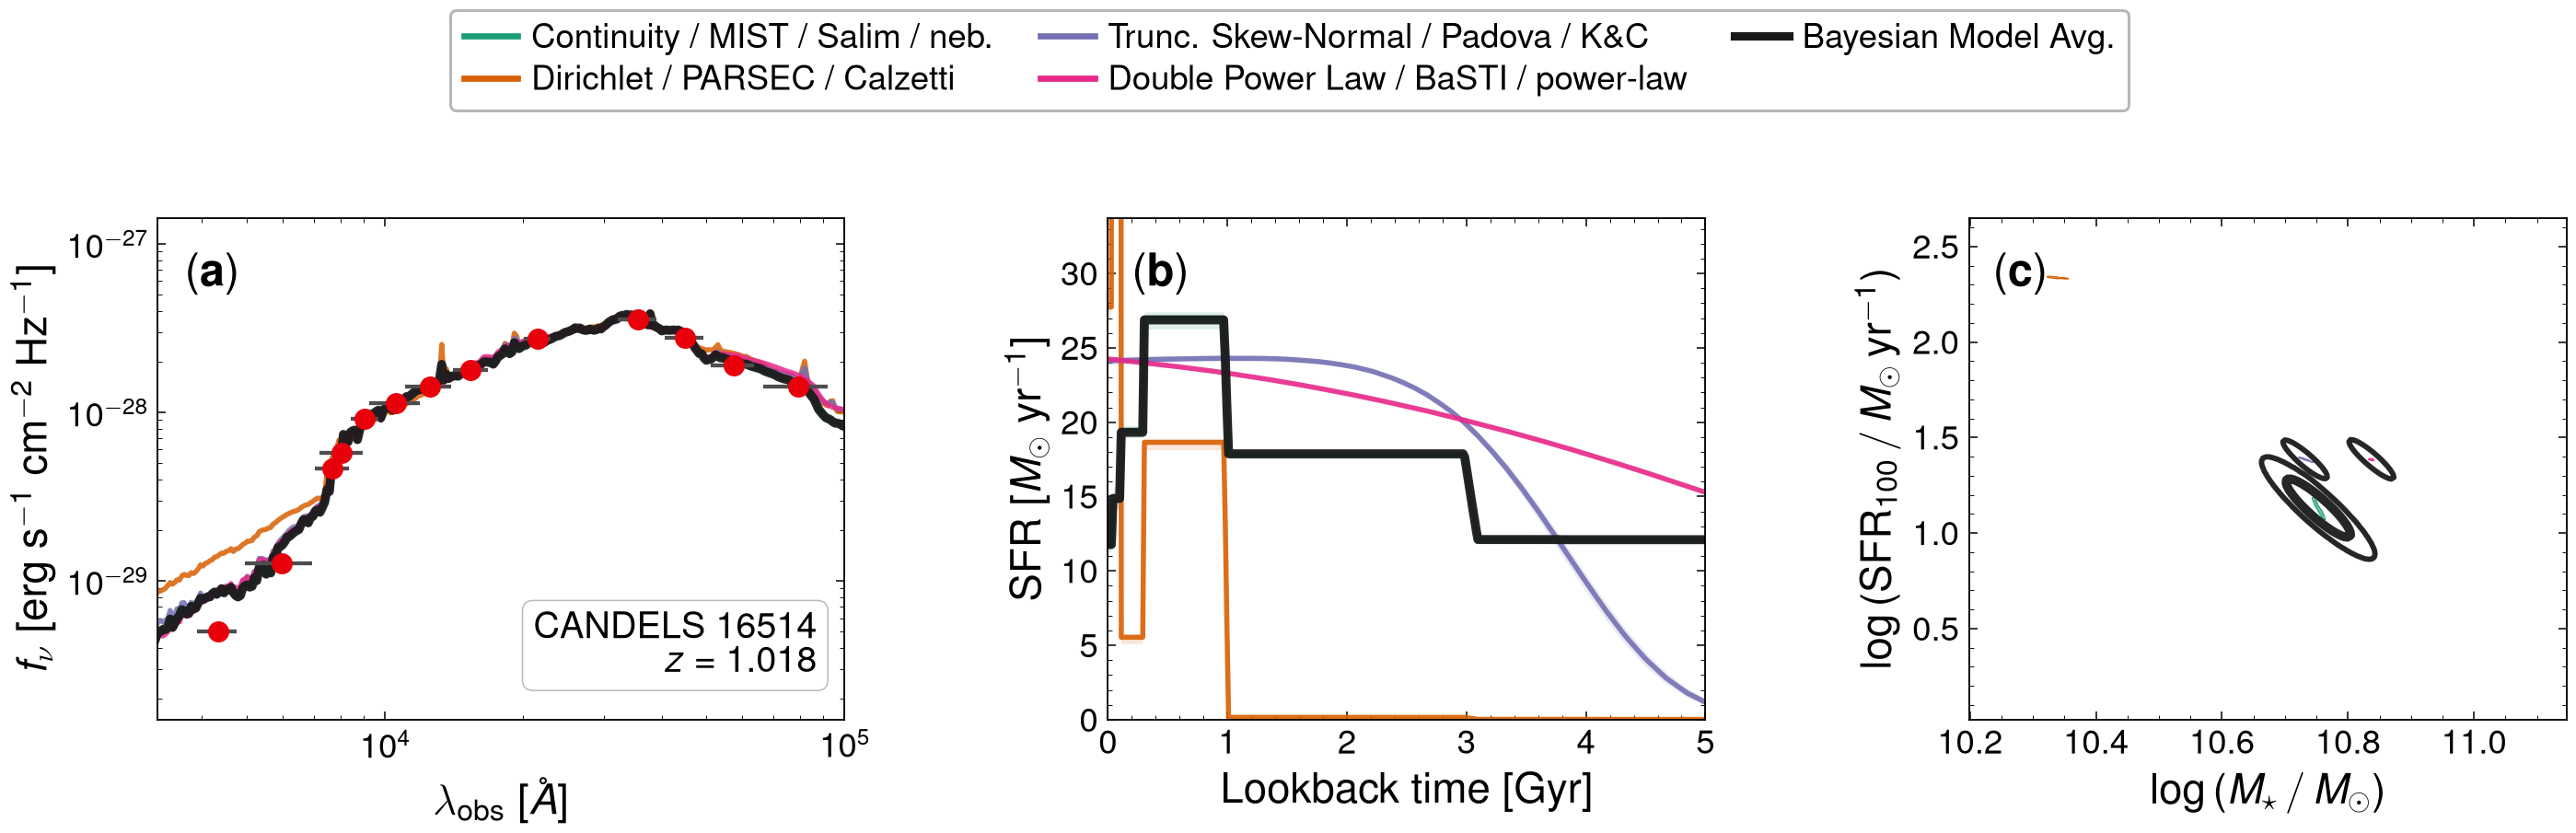

CANDELS 16514: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [19]:
plot_galaxy(16514)

In [20]:
show_timings(16514)

CANDELS 16514  (z = 1.018, 13 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):   9.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     13.3    -201.9
  Dirichlet / PARSEC / Calzetti      10     11.2    -733.9
  Trunc. Skew-Normal / Padova / K\&C  8     14.6    -303.1
  Double Power Law / BaSTI / power-law  6     11.4    -623.9
  4-config threaded wall-clock              90.1   (vs 50.4s summed)


### CANDELS 18160

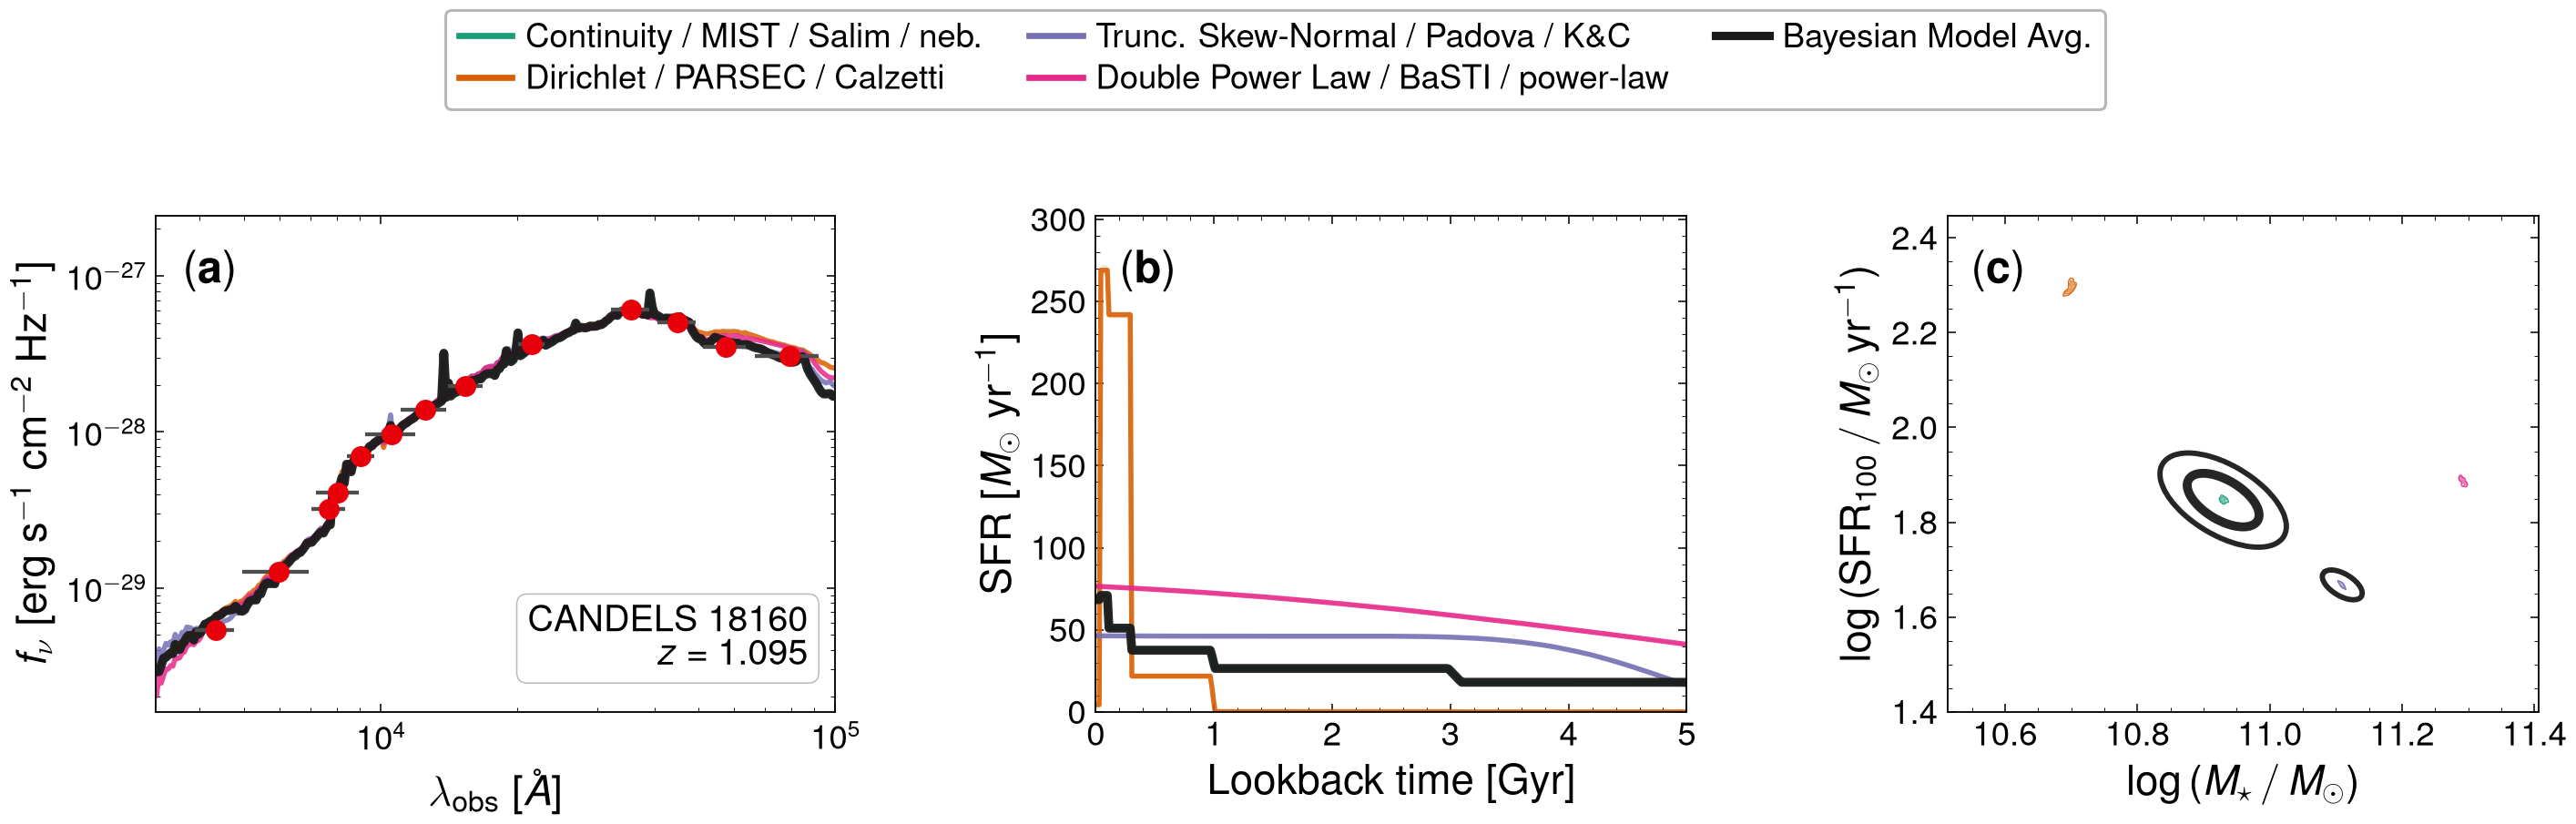

CANDELS 18160: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [21]:
plot_galaxy(18160)

In [22]:
show_timings(18160)

CANDELS 18160  (z = 1.095, 13 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):   8.6 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     13.8    -495.6
  Dirichlet / PARSEC / Calzetti      10     12.8   -1215.1
  Trunc. Skew-Normal / Padova / K\&C  8     13.0    -785.6
  Double Power Law / BaSTI / power-law  6     10.2   -1054.1
  4-config threaded wall-clock              90.0   (vs 49.7s summed)


### CANDELS 15775

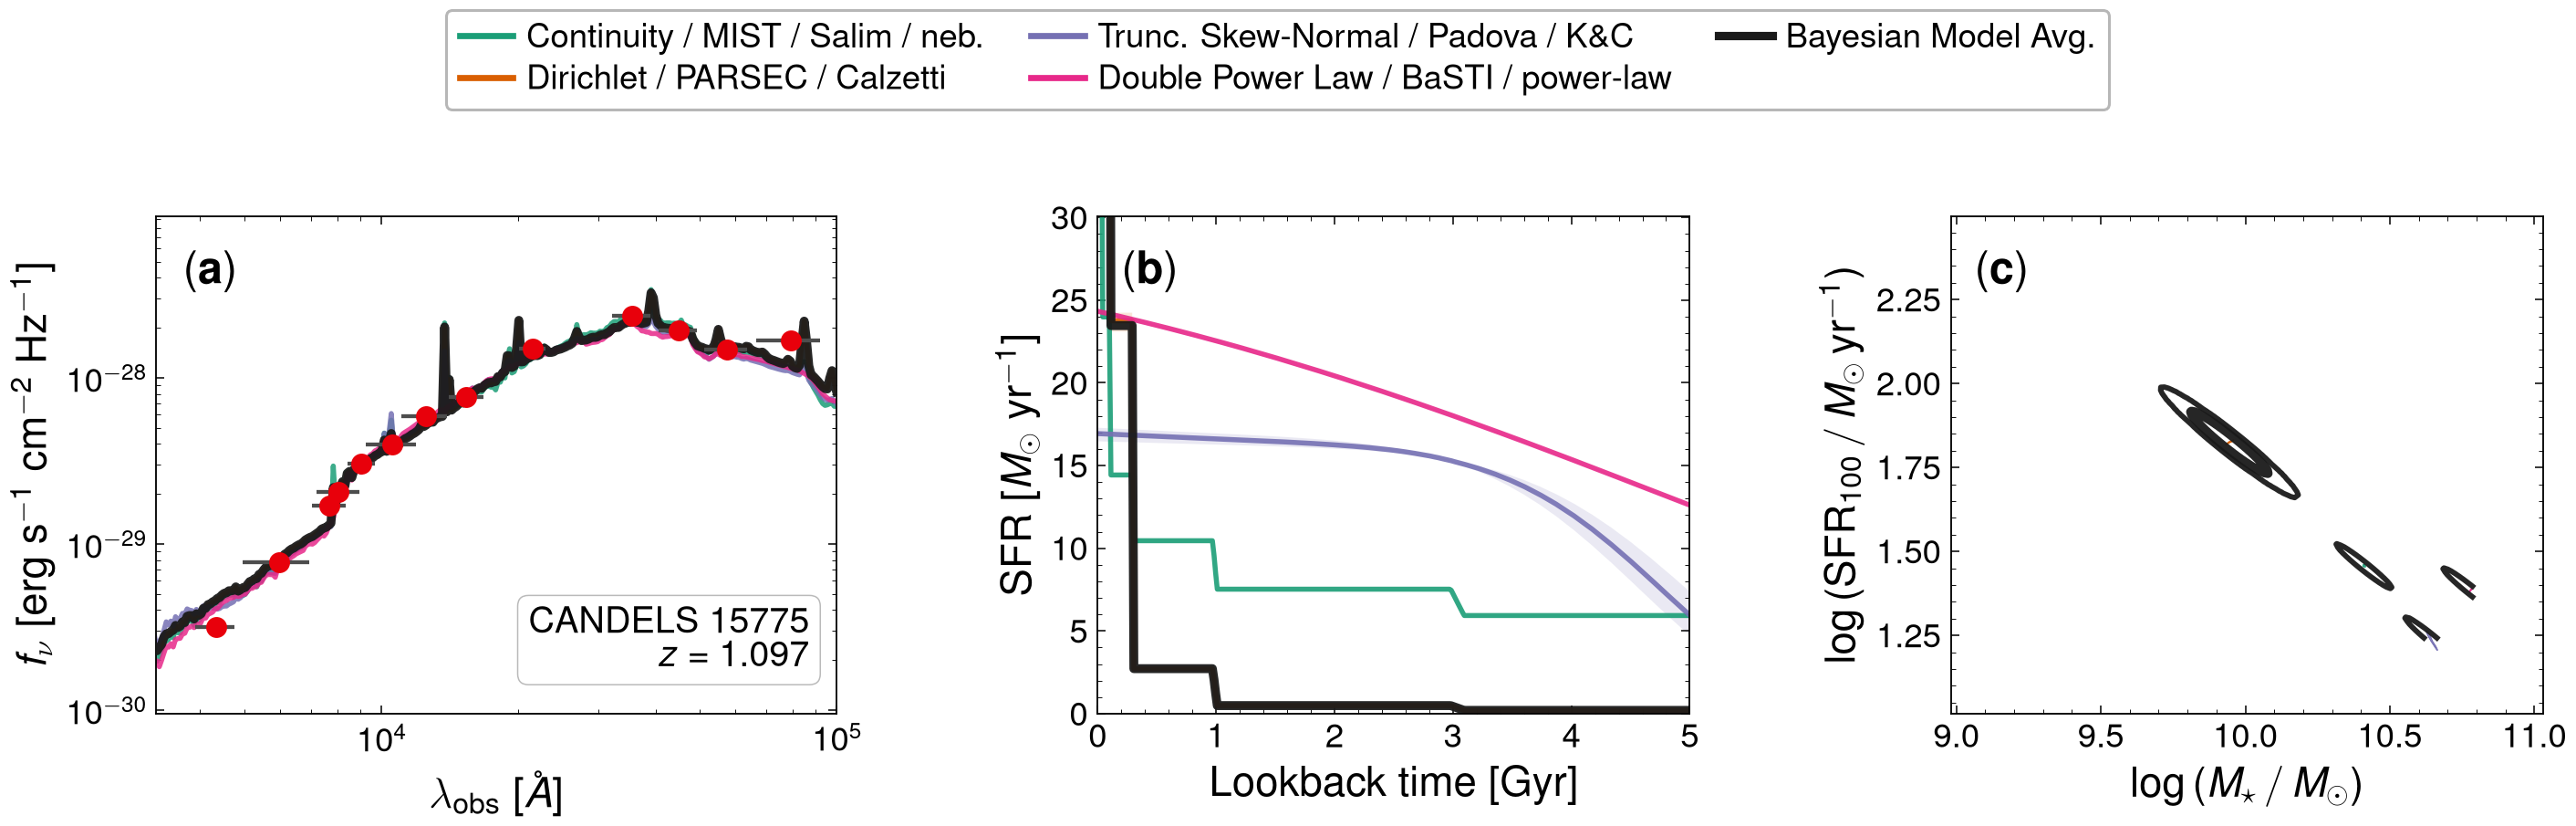

CANDELS 15775: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [23]:
plot_galaxy(15775)

In [24]:
show_timings(15775)

CANDELS 15775  (z = 1.097, 13 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):   7.9 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     13.4    -679.5
  Dirichlet / PARSEC / Calzetti      10     10.8    -482.5
  Trunc. Skew-Normal / Padova / K\&C  8     13.2   -1442.9
  Double Power Law / BaSTI / power-law  6     10.8   -3170.4
  4-config threaded wall-clock              97.2   (vs 48.2s summed)


### CANDELS 13097

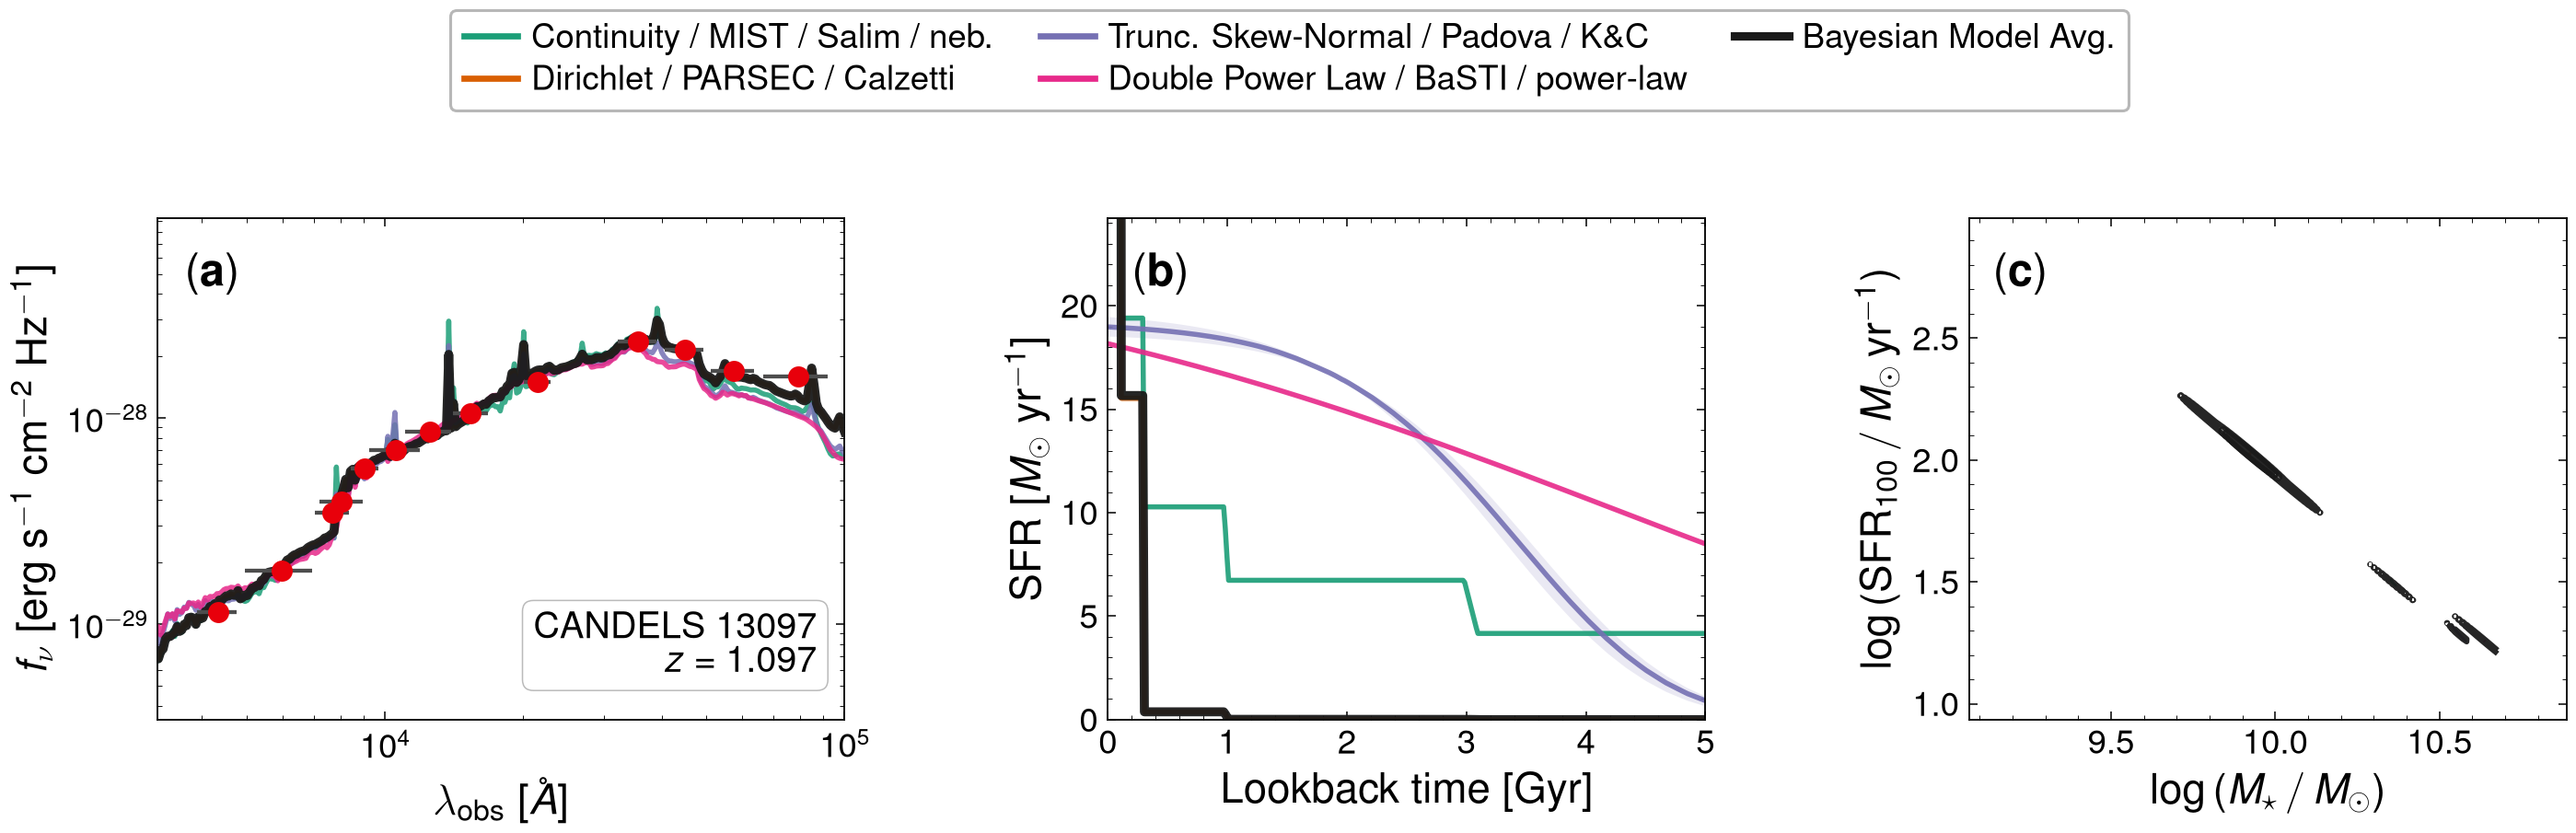

CANDELS 13097: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [25]:
plot_galaxy(13097)

In [26]:
show_timings(13097)

CANDELS 13097  (z = 1.097, 13 bands) — hmc_is
  build (4 models, incl. precompute publish + first compile):   8.5 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     12.0    -866.6
  Dirichlet / PARSEC / Calzetti      10      9.4    -380.1
  Trunc. Skew-Normal / Padova / K\&C  8     12.8   -2237.9
  Double Power Law / BaSTI / power-law  6     10.5   -4391.3
  4-config threaded wall-clock              98.1   (vs 44.7s summed)


## 11. Error floor: systematic + template uncertainty

Above, the evidence is decisive and BMA collapses to one model. Catalog errors are statistical only; they omit systematics (zero-point, aperture, filter curves) and template imperfection (SPS models accurate to ~few percent). Adding a fractional error floor in quadrature makes evidences comparable and spreads BMA weight:

$$\sigma_\mathrm{eff}^2 = \sigma_\mathrm{cat}^2 + (f_\mathrm{floor}\,f_\nu)^2$$

With a 10% floor, the BMA averages configurations, reflecting honest model uncertainty.

In [27]:
ERROR_FLOOR = 0.10  # 10% systematic + template-error floor, added in quadrature
FLOOR_IDS = [18160, 17418]  # picked (by a weight-entropy screen) to show real averaging
galaxies_floor = {}
for gal_idx in [int(np.where(ids == g)[0][0]) for g in FLOOR_IDS]:
    gal_id, z, names, fnu, sigma_cat = extract_photometry(gal_idx)
    sigma = jnp.sqrt(sigma_cat**2 + (ERROR_FLOOR * fnu) ** 2)  # inflated uncertainty
    obs = Observation(photometry=Photometry.from_names(names))
    models = build_configs(z, obs)
    posteriors = {route: {} for route in ROUTES}
    fit_timings = {route: {} for route in ROUTES}

    with ThreadPoolExecutor(max_workers=len(CONFIG_ORDER)) as ex:
        futs = []
        for route, route_kwargs in ROUTES.items():
            for cfg in CONFIG_ORDER:
                fut = ex.submit(
                    fit_one, models[cfg], fnu, sigma, gal_id=gal_id, cfg=cfg, **route_kwargs
                )
                futs.append((route, cfg, fut))
        for route, cfg, fut in futs:
            _, post, dt = fut.result()
            posteriors[route][cfg] = post
            fit_timings[route][cfg] = dt

    g = dict(z=z, names=names, fnu=np.asarray(fnu), sigma=np.asarray(sigma),
             models=models, posteriors=posteriors, build_s=0.0,
             fit_timings=fit_timings)  # fmt: skip
    # Inflated errors can pin a posterior to a prior bound, where the IS
    # evidence is legitimately unavailable; fall back to the calibrated NSS
    # weights for this demonstration rather than dying.
    try:
        g["weights"] = route_weights(posteriors[HEADLINE_ROUTE])
        weight_route = HEADLINE_ROUTE
    except ValueError as e:
        print(f"  ⚠ {HEADLINE_ROUTE} evidence unusable under the floor ({e}); using NSS weights")
        g["weights"] = route_weights(posteriors["nss"])
        weight_route = "nss"
    g["spec"], g["sfh"], g["props"] = collect_predictions(g, HEADLINE_ROUTE)
    galaxies_floor[gal_id] = g
    wstr = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id} (floor {ERROR_FLOOR:.0%}):  BMA weights ({weight_route})  {wstr}")

  ⚠ hmc_is evidence unusable under the floor (Model 'A' has invalid log_evidence: nan. Refit with an evidence method: 'nss', 'laplace', or 'hmc_is'.); using NSS weights


CANDELS 18160 (floor 10%):  BMA weights (nss)  A=0.16  B=0.00  C=0.27  D=0.57


  ⚠ hmc_is evidence unusable under the floor (Model 'A' has invalid log_evidence: nan. Refit with an evidence method: 'nss', 'laplace', or 'hmc_is'.); using NSS weights


CANDELS 17418 (floor 10%):  BMA weights (nss)  A=0.76  B=0.00  C=0.24  D=0.00


### CANDELS 18160 — 10% error floor (BMA averages four configurations)

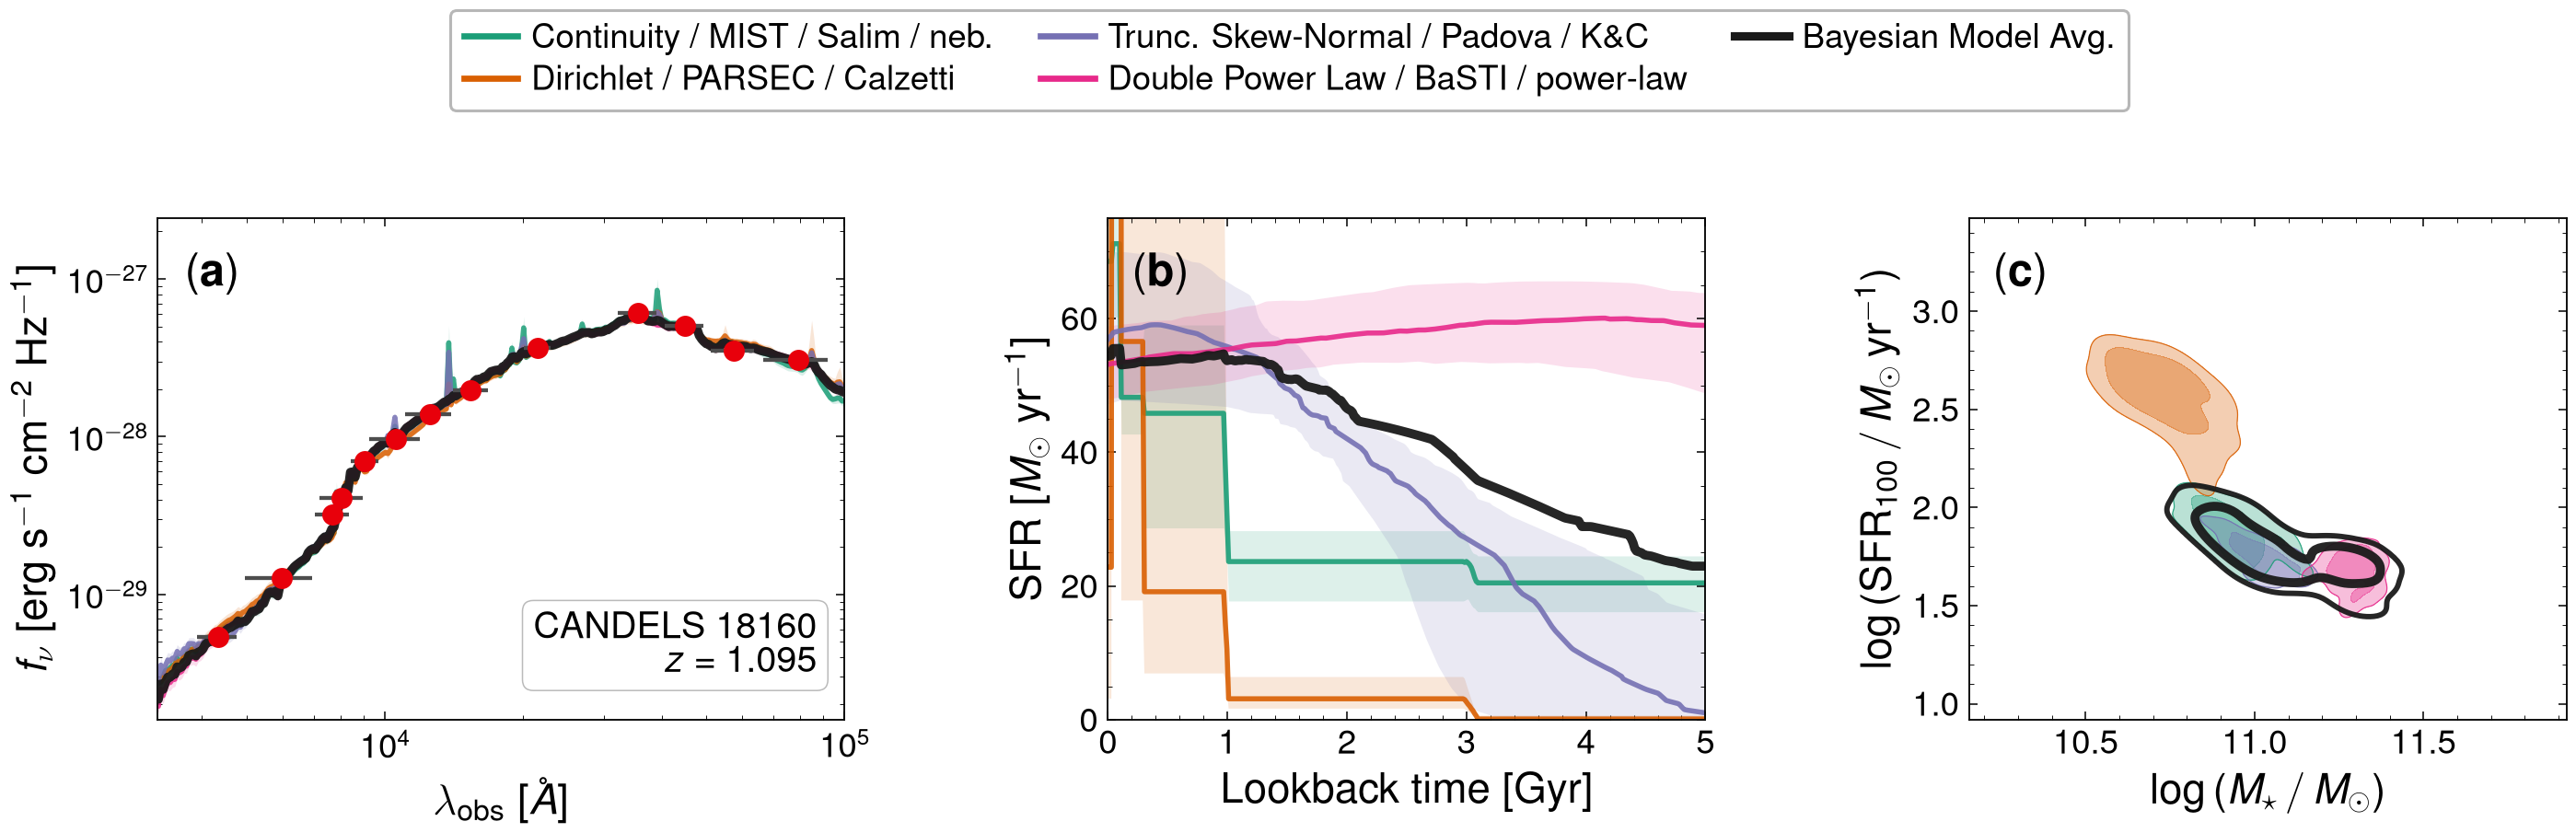

CANDELS 18160: BMA weights  A=0.16  B=0.00  C=0.27  D=0.57


In [28]:
plot_galaxy(18160, source=galaxies_floor, tag="_floor")

### CANDELS 17418 — 10% error floor (BMA averages three configurations)

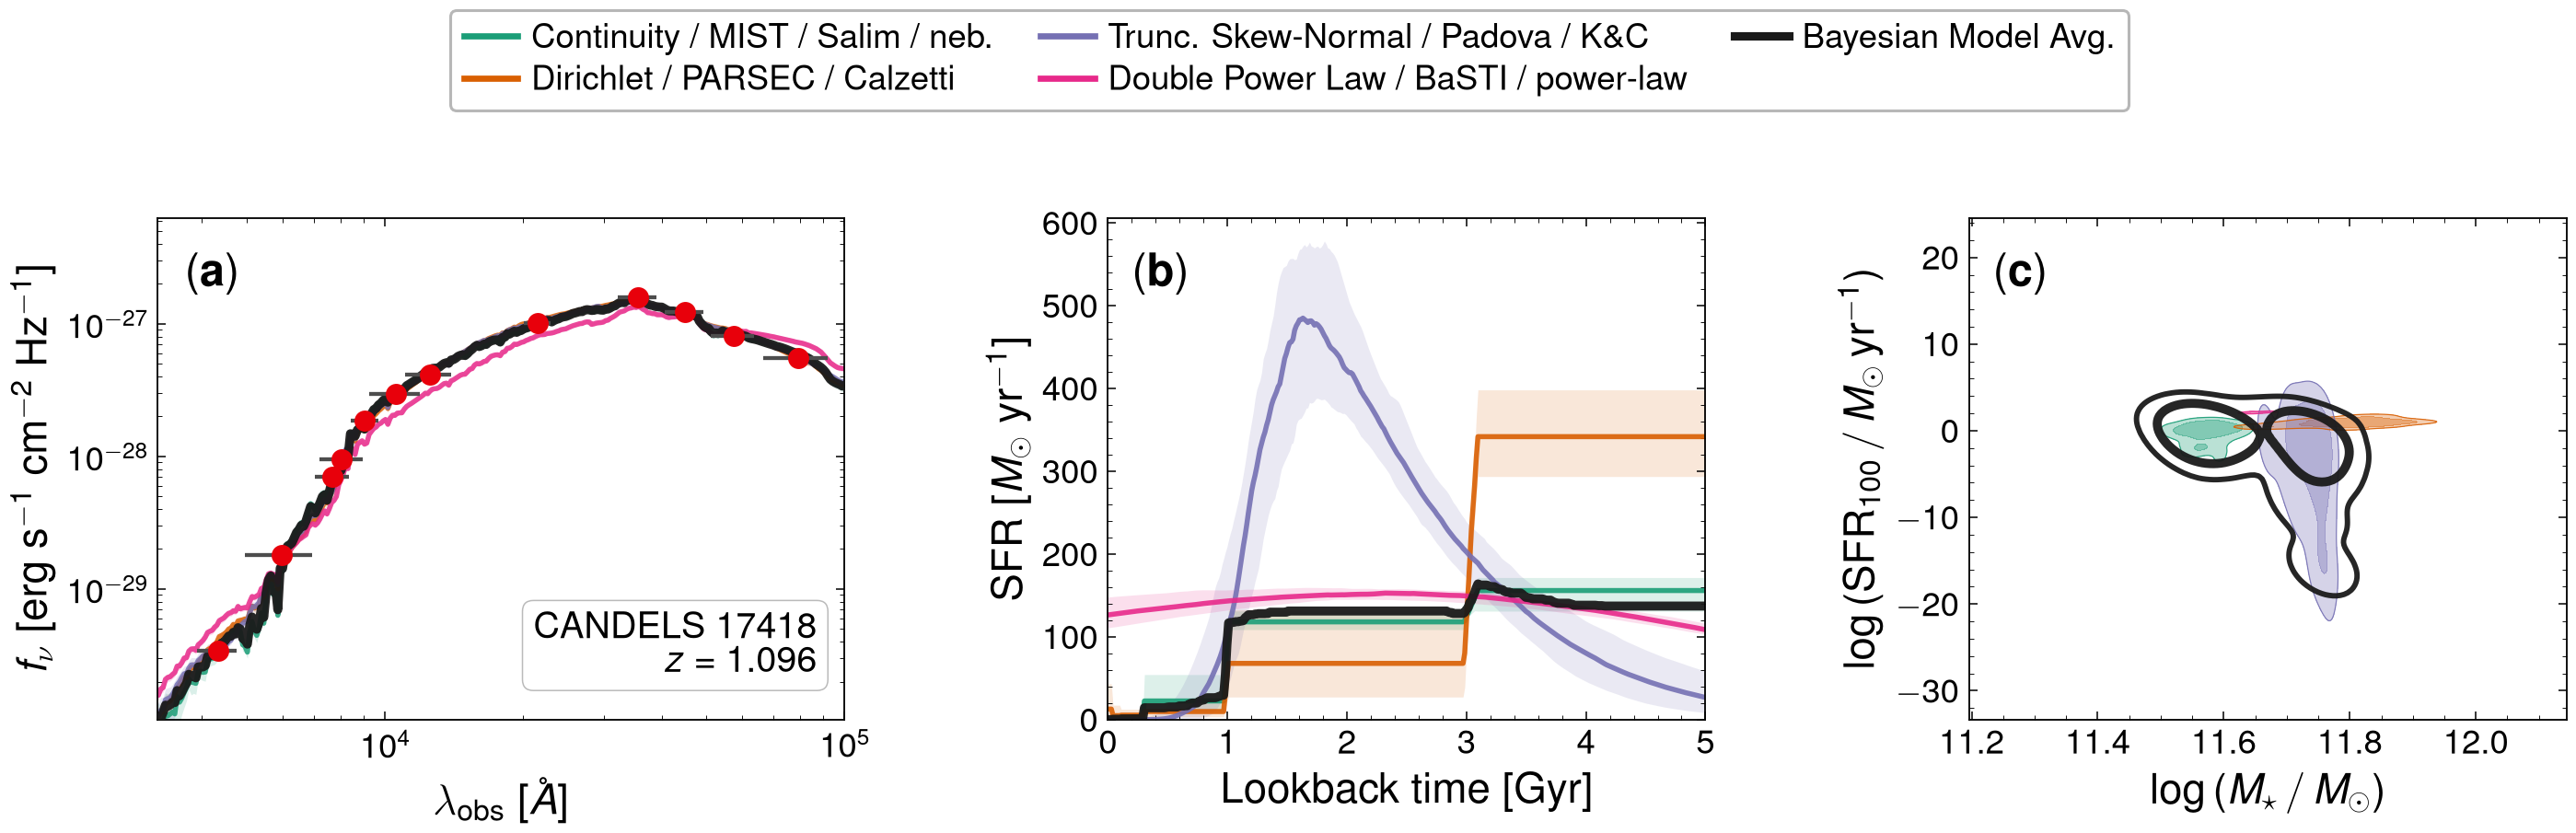

CANDELS 17418: BMA weights  A=0.76  B=0.00  C=0.24  D=0.00


In [29]:
plot_galaxy(17418, source=galaxies_floor, tag="_floor")

## 12. Summary

- BMA weights are rarely uniform; one or two configs dominate the evidence, pulling the average while preserving spread.
- Configurations disagree: changing SSP, SFH family, or dust law shifts $M_\star$ by ~0.1–0.3 dex at fixed photometry.
- Error floor determines whether averaging matters. Raw catalog errors collapse evidence to one model; ~10% systematic/template floor makes evidences comparable and activates BMA.
- Three evidence routes (NSS, Laplace, HMC+IS) show good consistency in logZ and BMA weights, validating the fast-preset approach for catalog-scale BMA.